This notebook is meant for developing/testing code related to the blazar-DESI cross-correlation project

In [1]:
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18
import astropy.cosmology.units as cu
from scipy.optimize import minimize
import astropy.constants as const
from astropy.table import Table 
import matplotlib.pyplot as plt  
from astropy import units as u 
from astropy.io import fits
from fftlog import pk2xi
from tqdm import tqdm 
from glob import glob
import healpy as hp 
import numpy as np
import pycorr
import pyccl 
import scipy

In [8]:
def sky_plotter(fits_file, nside):
    fname = fits_file.split('.')[0]
    data = fits.open(fits_file)[1].data
    ra = data['ra']
    dec = data['dec']
    
    gal_coords = np.empty((len(ra), 2))
    icrs_coords = SkyCoord(ra = ra * u.degree, dec = dec * u.degree, frame = 'icrs')
    gal_coords[:, 0] = icrs_coords.galactic.l.to(u.deg).value
    gal_coords[:, 1] = icrs_coords.galactic.b.to(u.deg).value
    #np.save(fname + "_gal_coords.npy", gal_coords)
    
    pix = hp.pixelfunc.ang2pix(nside, gal_coords[:, 0], gal_coords[:, 1], lonlat = True)
    npix = hp.nside2npix(nside)
    map_ = np.zeros(npix)
    map_.dtype = 'int'
    map_[pix] = int(1)
    hp.mollview(map_, title = fname, coord = 'G')
    #hp.fitsfunc.write_map(fname + '_map.fits', map_, coord = 'G', overwrite = True)

In [3]:
# Just a test..
#from compute_wtheta import compute_wtheta
#compute_wtheta('4LAC_DR3_FSRQ.fits', sample2 = '4LAC_DR3_BLL.fits')

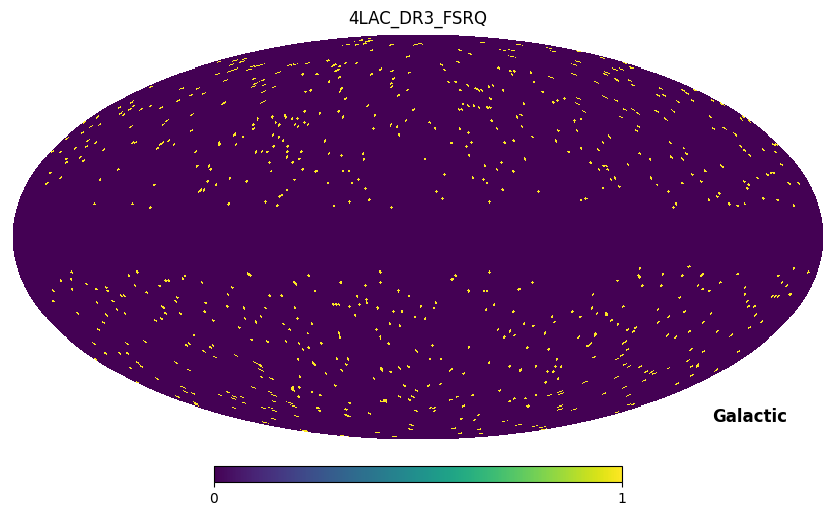

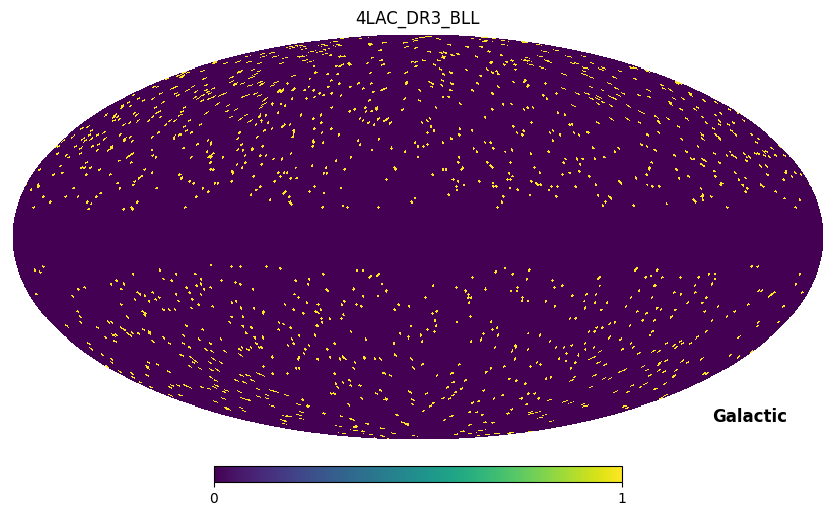

In [3]:
sky_plotter('4LAC_DR3_FSRQ.fits', 64)
sky_plotter('4LAC_DR3_BLL.fits', 64)

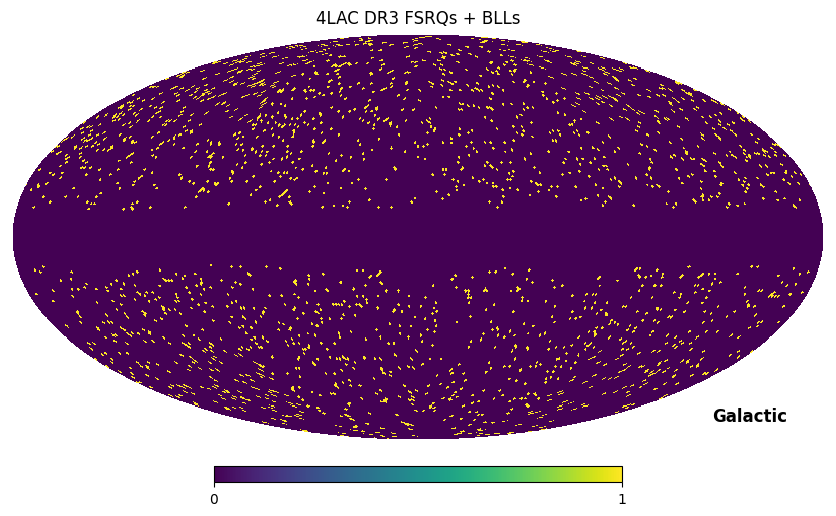

In [15]:
fsrq_map = hp.read_map('4LAC_DR3_FSRQ_map.fits')
bll_map = hp.read_map('4LAC_DR3_BLL_map.fits')
hp.mollview(fsrq_map | bll_map, title = '4LAC DR3 FSRQs + BLLs', coord = 'G')

In [17]:
fsrq_gal_coords = np.load("4LAC_DR3_FSRQ_gal_coords.npy")
bll_gal_coords = np.load("4LAC_DR3_BLL_gal_coords.npy")
coords = np.concatenate((fsrq_gal_coords, bll_gal_coords))

(360.0, 0.0)

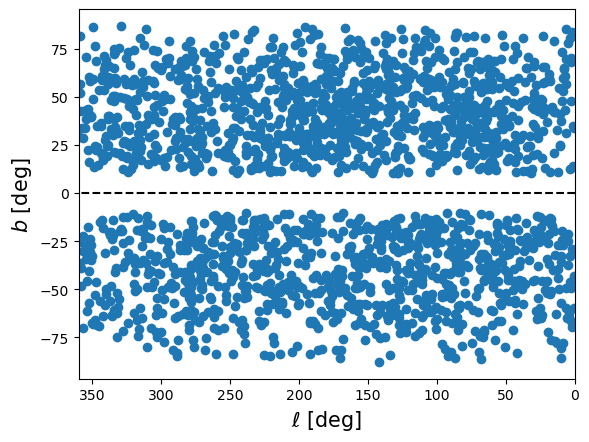

In [18]:
plt.scatter(coords[:, 0], coords[:, 1])
center = np.zeros((5, 2))
center[:, 0] = np.linspace(0., 360., 5)
plt.plot(center[:, 0], center[:, 1], linestyle = '--', color = 'k')
plt.xlabel(r'$\ell$' + ' [deg]', fontsize = 15)
plt.ylabel(r'$b$' + ' [deg]', fontsize = 15)
plt.xlim(360, 0)

In [19]:
min_dist_arr = []

for p1 in center:
    min_dist = np.inf
    
    for p2 in tqdm(coords):
        dist =  np.sqrt(((p1[0] - p2[0]) ** 2) + ((p1[1] - p2[1]) ** 2))

        if dist < min_dist:
            min_dist = dist 
        
    min_dist_arr.append(min_dist)

100%|██████████| 2134/2134 [00:00<00:00, 294564.76it/s]


In [20]:
dist = round(min(min_dist_arr))
print(dist)

11


(360.0, 0.0)

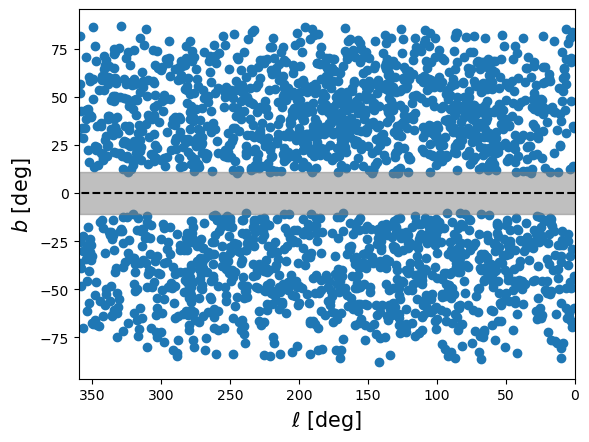

In [21]:
plt.scatter(coords[:, 0], coords[:, 1])
plt.plot(center[:, 0], center[:, 1], linestyle = '--', color = 'k')
plt.fill_between(center[:, 0], np.ones((len(center),)) * (-dist), np.ones((len(center),)) * dist, alpha = 0.5, color = 'grey')
plt.xlabel(r'$\ell$' + ' [deg]', fontsize = 15)
plt.ylabel(r'$b$' + ' [deg]', fontsize = 15)
plt.xlim(360, 0)

In [22]:
min_l = min(coords[:, 0])
print('min l:', min_l)
max_l = max(coords[:, 0])
print('max l:', max_l)
min_b = min(coords[:, 1])
print('min b:', min_b)
max_b = max(coords[:, 1])
print('max b:', max_b)

min l: 0.1552646831622595
max l: 359.90082249798337
min b: -87.68008956731327
max b: 86.76989229909942


In [23]:
randoms = np.empty((1380 * 50, 2)) # 50 times as many randoms as BLLs. For simplicity, we generate randoms from the union of both catalogues
n_success = 0 

while n_success < 1380 * 50:
    sin_p1 = np.random.uniform(-1, 1, 1)
    p1 = (np.arcsin(sin_p1) * 180 / np.pi)[0] 

    if (min_b < p1 < -dist) or (dist < p1 < max_b):
        p0 = np.random.uniform(0., 360., 1)[0]

        if min_l < p0 < max_l:
            randoms[n_success, 0] = p0
            randoms[n_success, 1] = p1
            n_success += 1

(360.0, 0.0)

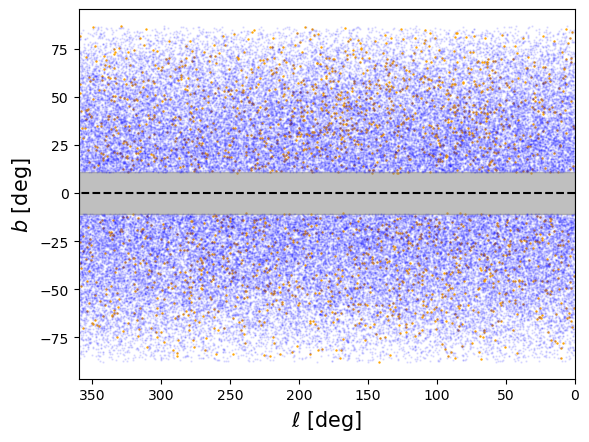

In [24]:
plt.scatter(coords[:, 0], coords[:, 1], s = 0.5, color = 'orange')
plt.plot(center[:, 0], center[:, 1], linestyle = '--', color = 'k')
plt.fill_between(center[:, 0], np.ones((len(center),)) * (-dist), np.ones((len(center),)) * dist, alpha = 0.5, color = 'grey')
plt.scatter(randoms[:, 0], randoms[:, 1], s = 0.5, alpha = 0.1, color = 'blue')
plt.xlabel(r'$\ell$' + ' [deg]', fontsize = 15)
plt.ylabel(r'$b$' + ' [deg]', fontsize = 15)
plt.xlim(360, 0)

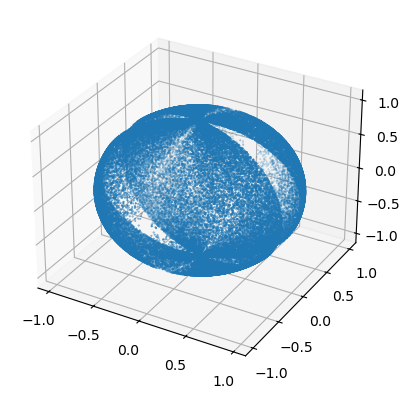

In [25]:
r = 1.
x = r * np.sin(np.radians(randoms[:, 0])) * np.cos(np.radians(randoms[:, 1])) 
y = r * np.sin(np.radians(randoms[:, 0])) * np.sin(np.radians(randoms[:, 1]))
z = r * np.cos(np.radians(randoms[:, 0]))

fig = plt.figure()
ax = plt.axes(projection = '3d')
ax.scatter(x, y, z, s = 0.1)

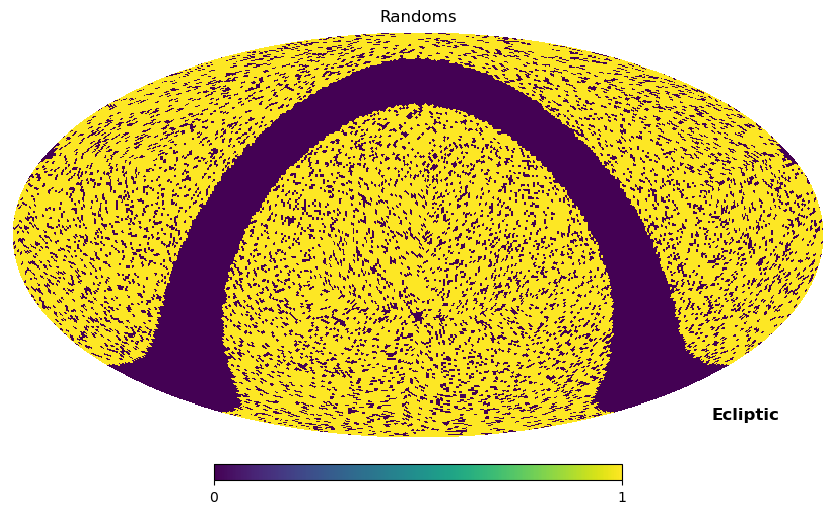

In [52]:
nside = 64
pix = hp.pixelfunc.ang2pix(nside, randoms[:, 0], randoms[:, 1], lonlat = True)
npix = hp.nside2npix(nside)
map_ = np.zeros(npix)
map_.dtype = 'int'
map_[pix] = int(1)
hp.mollview(map_, title = 'Randoms', coord = 'GE') # Appears uniform over the sphere! 
#plt.savefig('randoms.png', dpi = 400, bbox_inches = 'tight')

In [15]:
randoms_ = np.empty(randoms.shape)
gal_coords = SkyCoord(l = randoms[:, 0] * u.degree, b = randoms[:, 1] * u.degree, frame = 'galactic')
randoms_[:, 0] = gal_coords.icrs.ra.to(u.deg).value # Convert back to RA and Dec for pycorr 
randoms_[:, 1] = gal_coords.icrs.dec.to(u.deg).value

In [54]:
rand_t = Table()
rand_t['ra'] = randoms_[:, 0]
rand_t['dec'] = randoms_[:, 1]
rand_t.write('randoms.fits', format = 'fits', overwrite = True)

Moving on to correlation functions...

In [12]:
wtheta_fsrq = np.load('wtheta_fsrq.npy', allow_pickle = True).ravel()[0]
wtheta_bll = np.load('wtheta_bll.npy', allow_pickle = True).ravel()[0]
wtheta_cross = np.load('wtheta_cross.npy', allow_pickle = True).ravel()[0]

In [18]:
wtheta_cross.

array([ 6.75, 10.25, 13.75, 17.25, 20.75, 24.25, 27.75, 31.25, 34.75,
       38.25])

In [9]:
def wtheta_dvecs(pycorr_jk_obj, return_corrected_cov = False):
    sep = pycorr_jk_obj.sep 
    wtheta = pycorr_jk_obj.corr
    dvecs = []

    for i in pycorr_jk_obj.realizations:
        dvecs.append(pycorr_jk_obj.realization(i).corr)

    cov = np.cov(dvecs, rowvar = False, bias = True) * (len(pycorr_jk_obj.realizations) - 1)
    err = np.sqrt(cov.diagonal())

    res = np.empty((len(sep),3))
    res[:, 0] = sep
    res[:, 1] = wtheta
    res[:, 2] = err

    if return_corrected_cov == True:
        return res, (cov * (len(pycorr_jk_obj.realizations) - 1) / (len(pycorr_jk_obj.realizations) - len(sep) - 2))

    else:
        return res 

In [14]:
fsrq_arr = wtheta_dvecs(wtheta_fsrq)
bll_arr = wtheta_dvecs(wtheta_bll)
cross_arr = wtheta_dvecs(wtheta_cross)

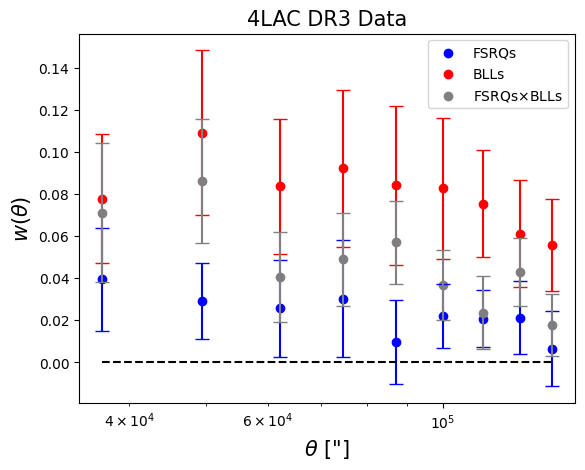

In [5]:
plt.scatter(fsrq_arr[:, 0] * 3600, fsrq_arr[:, 1], color = 'blue', label = 'FSRQs')
plt.errorbar(fsrq_arr[:, 0] * 3600, fsrq_arr[:, 1], yerr = fsrq_arr[:, 2], linestyle = '', capsize = 5, color = 'blue')
plt.scatter(bll_arr[:, 0] * 3600, bll_arr[:, 1], color = 'red', label = 'BLLs')
plt.errorbar(bll_arr[:, 0] * 3600, bll_arr[:, 1], yerr = bll_arr[:, 2], linestyle = '', capsize = 5, color = 'red')
plt.scatter(cross_arr[:, 0] * 3600, cross_arr[:, 1], color = 'grey', label = 'FSRQs' + r'$\times$' + 'BLLs')
plt.errorbar(cross_arr[:, 0] * 3600, cross_arr[:, 1], yerr = cross_arr[:, 2], linestyle = '', capsize = 5, color = 'grey')
plt.hlines(0, min(fsrq_arr[:, 0] * 3600), max(fsrq_arr[:, 0] * 3600), linestyle = '--', color = 'k')
plt.xscale('log')
plt.title('4LAC DR3 Data', fontsize = 15)
plt.xlabel(r'$\theta$' + ' ["]', fontsize = 15)
plt.ylabel(r'$w(\theta)$', fontsize = 15)
plt.legend(loc = 'best')
plt.savefig('4LAC_DR3_wtheta.png', dpi = 400, bbox_inches = 'tight')

In [6]:
wp_desi = np.load('wp_desi.npy', allow_pickle = True).ravel()[0]

In [7]:
sep = wp_desi.sep[1:, 0]
wp = wp_desi(pimax = 100.)[1:]

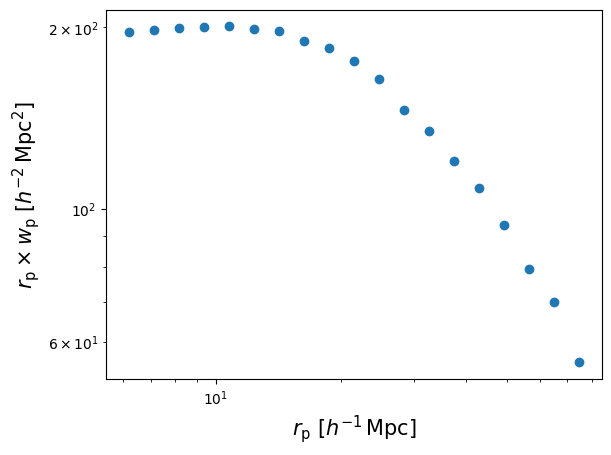

In [25]:
plt.scatter(sep, wp * sep)
plt.xlabel(r'$r_{\mathrm{p}}\,\,[h^{-1}\,\mathrm{Mpc}]$', fontsize = 15)
plt.ylabel(r'$r_{\mathrm{p}}\times w_{\mathrm{p}}\,\,[h^{-2}\,\mathrm{Mpc}^2]$', fontsize = 15)
plt.xscale('log')
plt.yscale('log')

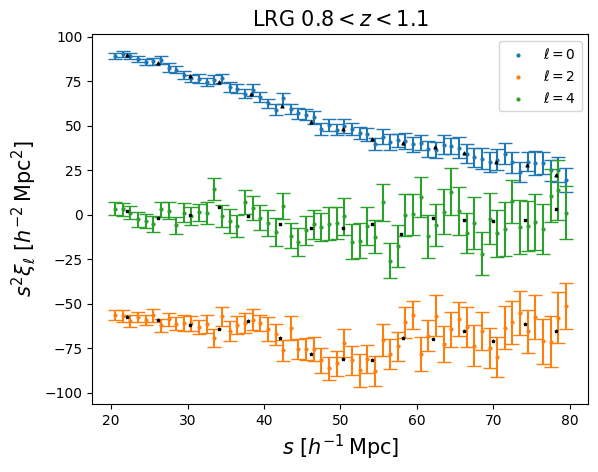

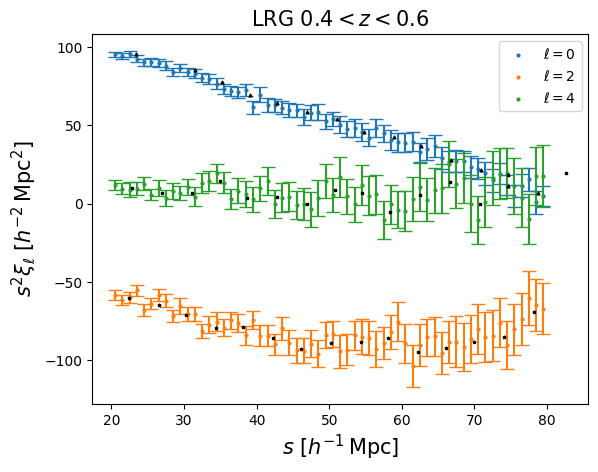

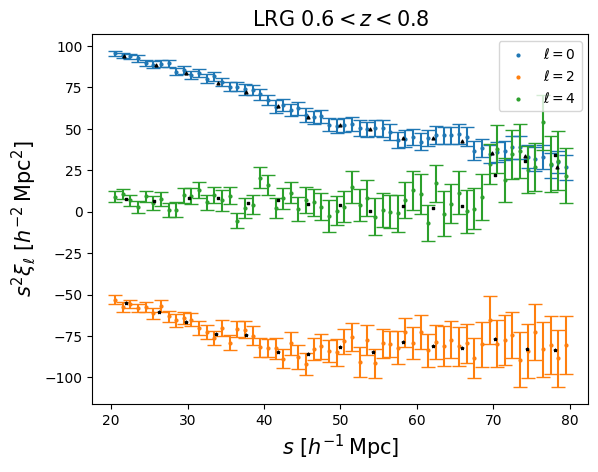

In [51]:
files = glob('eta_z*.npy')
z_bin_dict = {'z1':[0.4, 0.6], 'z2':[0.6, 0.8], 'z3':[0.8, 1.1]}
mu_midpts = (np.linspace(-1, 1, 200)[1:] + np.linspace(-1, 1, 200)[:-1]) / 2
dx = mu_midpts[1] - mu_midpts[0]
L2 = 0.5 * ((3 * (mu_midpts ** 2)) -1) # 2nd degree Legendre polynomial 
L4 = (1 / 8) * ((35 * (mu_midpts ** 4)) - (30 * (mu_midpts ** 2)) + 3) # 4th degree 

for f in files:
    z_bin = f.split('_')[-1].replace('.npy', '')
    bin_edges = z_bin_dict[z_bin]
    eta = np.load(f, allow_pickle = True).ravel()[0]
    
    ell_0 = 0.5 * np.sum(eta.corr * dx, axis = 1)
    ell_2 = 2.5 * np.sum(eta.corr * L2 * dx, axis = 1)
    ell_4 = 4.5 * np.sum(eta.corr * L4 * dx, axis = 1)

    dvecs = np.empty((len(eta.realizations), len(ell_0), 3)) # Each column is a different variable 

    for i in eta.realizations:
        corr = eta.realization(i).corr 
        ell_0_ = 0.5 * np.sum(corr * dx, axis = 1)
        ell_2_ = 2.5 * np.sum(corr * L2 * dx, axis = 1)
        ell_4_ = 4.5 * np.sum(corr * L4 * dx, axis = 1)

        dvecs[i, :, 0] = ell_0_
        dvecs[i, :, 1] = ell_2_
        dvecs[i, :, 2] = ell_4_
    
    err_0 = np.sqrt((np.cov(dvecs[:, :, 0], rowvar = False, bias = True) * (len(eta.realizations) - 1)).diagonal())
    err_2 = np.sqrt((np.cov(dvecs[:, :, 1], rowvar = False, bias = True) * (len(eta.realizations) - 1)).diagonal())
    err_4 = np.sqrt((np.cov(dvecs[:, :, 2], rowvar = False, bias = True) * (len(eta.realizations) - 1)).diagonal())

    desi_0 = np.loadtxt('desi_' + z_bin + '_0.txt', delimiter = ',')
    desi_2 = np.loadtxt('desi_' + z_bin + '_2.txt', delimiter = ',')
    desi_4 = np.loadtxt('desi_' + z_bin + '_4.txt', delimiter = ',')

    plt.scatter(eta.sep[:, 0], (eta.sep[:, 0] ** 2) * ell_0, label = r'$\ell=0$', s = 4)
    plt.errorbar(eta.sep[:, 0], (eta.sep[:, 0] ** 2) * ell_0, yerr = (eta.sep[:, 0] ** 2) * err_0, linestyle = '', capsize = 5)
    plt.scatter(desi_0[:, 0], desi_0[:, 1], s = 4, marker = '^', color = 'k', zorder = 100)
    plt.scatter(eta.sep[:, 0], (eta.sep[:, 0] ** 2) * ell_2, label = r'$\ell=2$', s = 4)
    plt.errorbar(eta.sep[:, 0], (eta.sep[:, 0] ** 2) * ell_2, yerr = (eta.sep[:, 0] ** 2) * err_2, linestyle = '', capsize = 5)
    plt.scatter(desi_2[:, 0], desi_2[:, 1], s = 4, marker = 's', color = 'k', zorder = 101)
    plt.scatter(eta.sep[:, 0], (eta.sep[:, 0] ** 2) * ell_4, label = r'$\ell=4$', s = 4)
    plt.errorbar(eta.sep[:, 0], (eta.sep[:, 0] ** 2) * ell_4, yerr = (eta.sep[:, 0] ** 2) * err_4, linestyle = '', capsize = 5)
    plt.scatter(desi_4[:, 0], desi_4[:, 1], s = 4, marker = '*', color = 'k', zorder = 102)
    plt.title('LRG ' + str(bin_edges[0]) + r'$<z<$' + str(bin_edges[1]), fontsize = 15)
    plt.xlabel(r'$s\,\,[h^{-1}\,\mathrm{Mpc}]$', fontsize = 15)
    plt.ylabel(r'$s^2\xi_\ell\,\,[h^{-2}\,\mathrm{Mpc}^2]$', fontsize = 15)
    plt.legend(loc = 'best')
    plt.savefig('desi_lrg_' + z_bin + '.png', dpi = 400, bbox_inches = 'tight')
    plt.show()

Now, we want to test if the differences between $w(\theta)$ are because of the randoms or the samples themselves. So, we will downsample one to match the density of the other...

In [98]:
fsrq = fits.open('4LAC_DR3_FSRQ.fits')[1].data
bll = fits.open('4LAC_DR3_BLL.fits')[1].data
dict_ = {'fsrq': len(fsrq['ra']), 'bll': len(bll['ra'])}
larger_idx = list(dict_.values()).index(max(dict_.values()))
larger_samp = list(dict_.keys())[larger_idx]
larger_samp 

'bll'

Therefore we downsample BLL objects...

In [99]:
indices_to_keep = np.random.choice(dict_['bll'], size = dict_['fsrq'], replace = False)
t = Table()
t['ra'] = bll['ra'][indices_to_keep]
t['dec'] = bll['dec'][indices_to_keep]
t['flags'] = bll['flags'][indices_to_keep]
t['class'] = bll['class'][indices_to_keep]
t['z'] = bll['z'][indices_to_keep]

print(len(t) == len(fsrq['ra']))
t.write('4LAC_DR3_downsampled_BLL.fits', format = 'fits', overwrite = True)

True


In [101]:
from compute_wtheta import compute_wtheta
res = compute_wtheta('4LAC_DR3_downsampled_BLL.fits', 20, 'wtheta_downsampled_bll')

In [8]:
wtheta_downsampled_bll = np.load('wtheta_downsampled_bll.npy', allow_pickle = True).ravel()[0]

In [9]:
downsampled_bll_arr = wtheta_dvecs(wtheta_downsampled_bll)

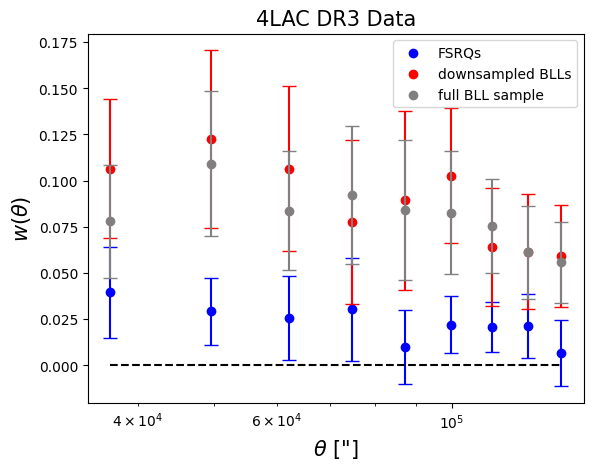

In [10]:
plt.scatter(fsrq_arr[:, 0] * 3600, fsrq_arr[:, 1], color = 'blue', label = 'FSRQs')
plt.errorbar(fsrq_arr[:, 0] * 3600, fsrq_arr[:, 1], yerr = fsrq_arr[:, 2], linestyle = '', capsize = 5, color = 'blue')
plt.scatter(downsampled_bll_arr[:, 0] * 3600, downsampled_bll_arr[:, 1], color = 'red', label = 'downsampled BLLs')
plt.errorbar(downsampled_bll_arr[:, 0] * 3600, downsampled_bll_arr[:, 1], yerr = downsampled_bll_arr[:, 2], linestyle = '', capsize = 5, color = 'red')
plt.scatter(bll_arr[:, 0] * 3600, bll_arr[:, 1], color = 'grey', label = 'full BLL sample')
plt.errorbar(bll_arr[:, 0] * 3600, bll_arr[:, 1], color = 'grey', yerr = bll_arr[:, 2], linestyle = '', capsize = 5)
plt.hlines(0, min(fsrq_arr[:, 0] * 3600), max(fsrq_arr[:, 0] * 3600), linestyle = '--', color = 'k')
plt.xscale('log')
plt.title('4LAC DR3 Data', fontsize = 15)
plt.xlabel(r'$\theta$' + ' ["]', fontsize = 15)
plt.ylabel(r'$w(\theta)$', fontsize = 15)
plt.legend(loc = 'best')

In [22]:
data = fits.open('DESI_DR1_LRG.fits')[1].data
ra = data['ra']
dec = data['dec']

(360.0, 0.0)

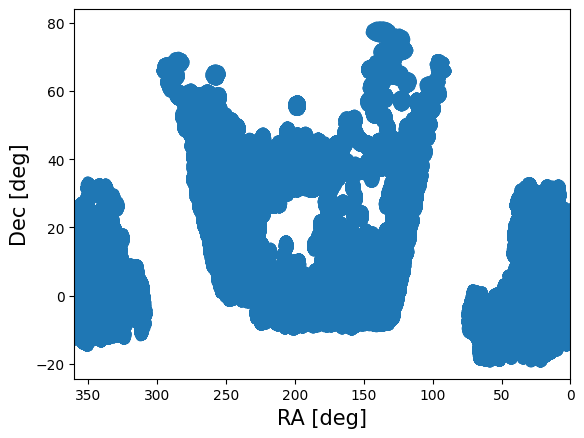

In [23]:
plt.scatter(ra, dec)
plt.xlabel('RA [deg]', fontsize = 15)
plt.ylabel('Dec [deg]', fontsize = 15)
plt.xlim(360, 0)

Can make a simple declination cut to make pair counts faster. 

setting the output map dtype to [dtype('int64')]


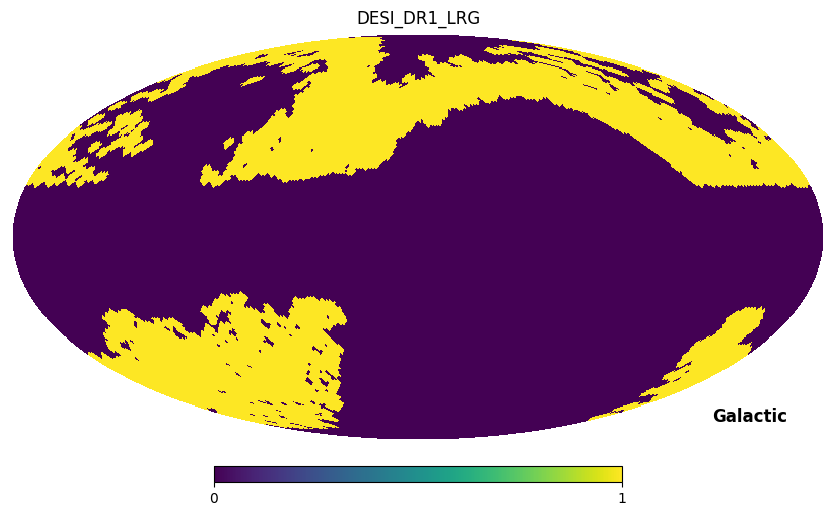

In [14]:
sky_plotter('DESI_DR1_LRG.fits', 64)

In [16]:
desi_map = hp.read_map('DESI_DR1_LRG_map.fits')

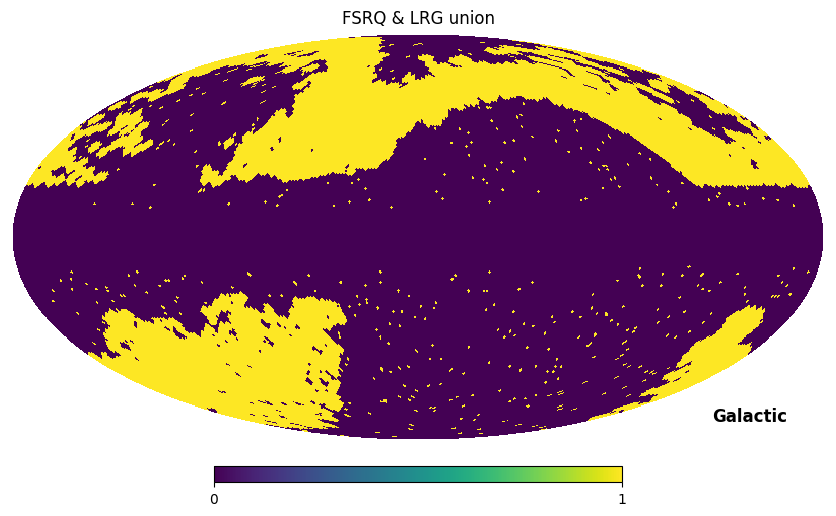

In [20]:
hp.mollview(fsrq_map | desi_map, title = 'FSRQ & LRG union', coord = 'G')

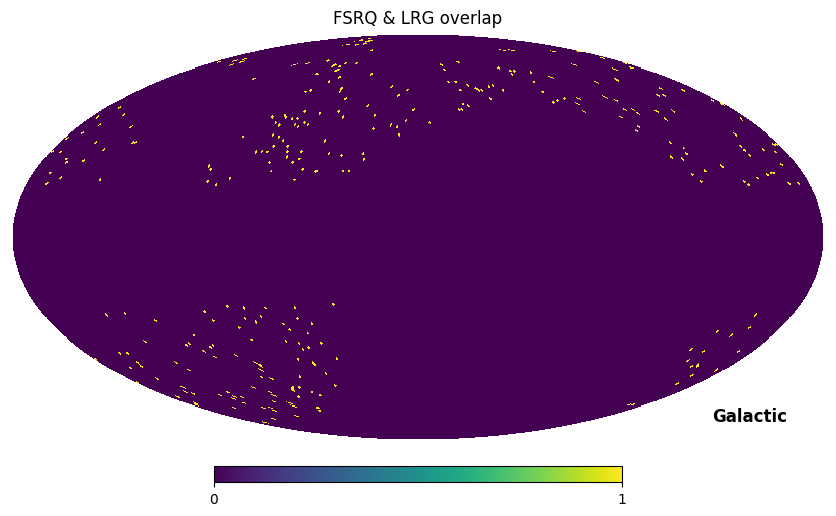

In [19]:
hp.mollview(fsrq_map & desi_map, title = 'FSRQ & LRG overlap', coord = 'G')

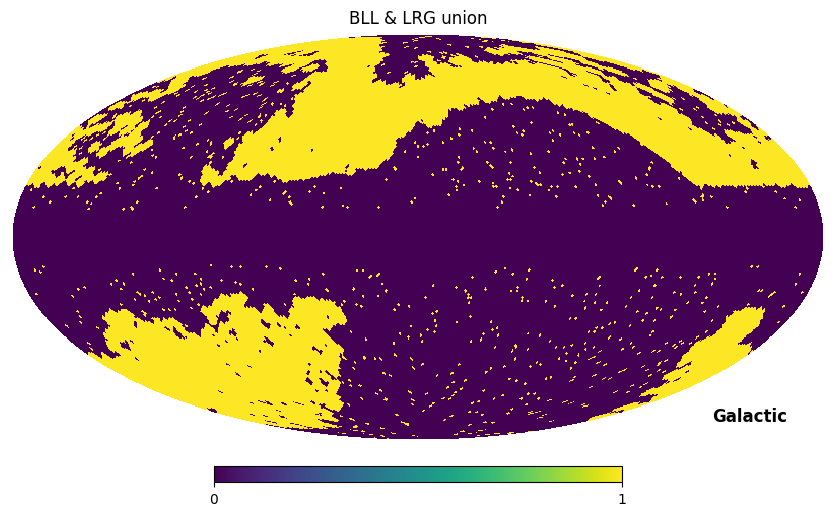

In [18]:
hp.mollview(bll_map | desi_map, title = 'BLL & LRG union', coord = 'G')

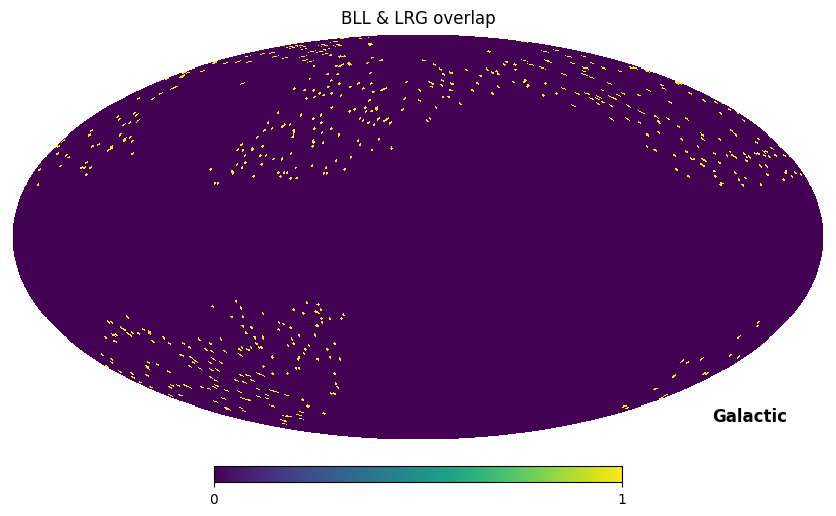

In [21]:
hp.mollview(bll_map & desi_map, title = 'BLL & LRG overlap', coord = 'G')

In [5]:
# Playing around with the LAT detection threshold file...
hdul = fits.open('detthresh_P8R3_12years_PL22.fits')

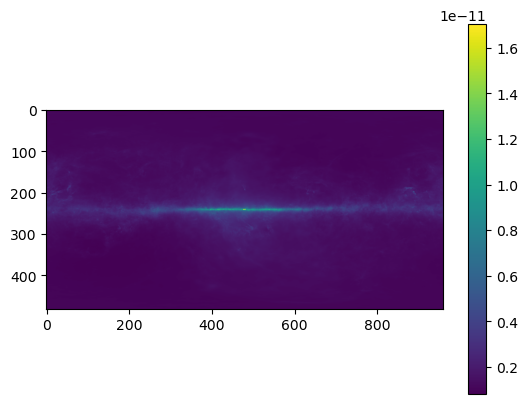

In [6]:
plt.imshow(hdul[0].data)
plt.colorbar()
#plt.savefig('detec_thresh.png', dpi = 400, bbox_inches = 'tight')

The above appears to be the correct map...

In [116]:
hdul[0].data.shape 

(481, 960)

In [117]:
max(hdul[0].data.flatten())

np.float32(1.702619e-11)

In [118]:
hdul.info()

Filename: detthresh_P8R3_12years_PL22.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      36   (960, 481)   float32   


Galactic latitude goes from 0 to 360, and longitude from 90 to -90. Each pixel therefore must represent a bin.

In [119]:
lat_bins = np.linspace(0, 360, num = hdul[0].data.shape[-1] + 1)
long_bins = np.linspace(-90, 90, num = hdul[0].data.shape[0] + 1)
lat_bins[:10]

array([0.   , 0.375, 0.75 , 1.125, 1.5  , 1.875, 2.25 , 2.625, 3.   ,
       3.375])

In [7]:
x_pix = np.arange(0, hdul[0].data.shape[-1], 1)
y_pix = np.arange(0, hdul[0].data.shape[0], 1)
x_pix[:10]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

Code below assigns a detection threshold to a given lat, long coordinate

In [9]:
hdul = fits.open('detthresh_P8R3_12years_PL22.fits')
lat_bins = np.linspace(0, 360, num = hdul[0].data.shape[-1] + 1)
long_bins = np.linspace(-90, 90, num = hdul[0].data.shape[0] + 1)
x_pix = np.arange(0, hdul[0].data.shape[-1], 1)
y_pix = np.arange(0, hdul[0].data.shape[0], 1)

def assign_thresh(lat, long):
    if (0 <= lat <= 360) and (-90 <= long <= 90):
        try: 
            i = np.where(lat_bins < lat)[0][-1]
        except: 
            i = 0
            
        try:
            j = np.where(long_bins < long)[0][-1]
        except: 
            j = 0

        x = x_pix[i]
        y = y_pix[j]
        flux = hdul[0].data[y, x]
        
        return [lat_bins[i], lat_bins[i + 1]], [long_bins[j], long_bins[j + 1]], flux 

    else:
        print('reformat')

In [10]:
lats, longs = np.meshgrid((lat_bins[1:] + lat_bins[:-1]) / 2, (long_bins[1:] + long_bins[:-1]) / 2)
points = np.stack((lats.flatten(), longs.flatten()), axis = 1)
N_pix = len(points)
blazar_data = fits.open('table-4LAC-DR3-h.fits')[1].data

def create_randoms(sample):
    if (sample == 'fsrq') or sample == 'FSRQ':
        indices = np.where(blazar_data['CLASS'] == 'fsrq')[0].tolist() + np.where(blazar_data['CLASS'] == 'FSRQ')[0].tolist()

    elif (sample == 'bll') or ('BLL'): 
        indices = np.where(blazar_data['CLASS'] == 'bll')[0].tolist() + np.where(blazar_data['CLASS'] == 'BLL')[0].tolist()

    cat_fluxes = blazar_data['Energy_Flux100'][indices]
    tot = len(indices)
    target = 40 * tot 
    lat_rands = []
    long_rands = []

    for i, j in tqdm(points):
        lat_bin, long_bin, thresh = assign_thresh(i, j)
        N_blazars = len(np.where(cat_fluxes > thresh)[0])

        if N_blazars != 0: 
            f = N_blazars / tot 
            sin_long = np.random.uniform(np.sin(np.radians(long_bin[0])), np.sin(np.radians(long_bin[1])), 100)
            long = np.degrees(np.arcsin(sin_long))
            lat = np.random.uniform(lat_bin[0], lat_bin[1], 100)
            indices_ =  np.random.choice(100, round(f * 100), replace = False)
            lat_rands.append(lat[indices_])
            long_rands.append(long[indices_])
                    
    lat_rands_ = np.concatenate(lat_rands)
    long_rands_ = np.concatenate(long_rands)

    indices__ = np.where(abs(long_rands_) > 10)[0]
    lat_rands_ = lat_rands_[indices__]
    long_rands_ = long_rands_[indices__]

    if len(lat_rands_) > target:
        indices___ = np.random.choice(len(lat_rands_), int(target), replace = False)

    else:
        indices___ = np.linspace(0, len(lat_rands_), 1)

    lat_rands_ = lat_rands_[indices___]
    long_rands_ = long_rands_[indices___]
    gal_coords = SkyCoord(l = lat_rands_ * u.degree, b = long_rands_ * u.degree, frame = 'galactic')
    ra_rands = gal_coords.icrs.ra.to(u.deg).value
    dec_rands = gal_coords.icrs.dec.to(u.deg).value

    return ra_rands, dec_rands 

In [4]:
ra_rands, dec_rands = create_randoms('fsrq')

100%|██████████| 461760/461760 [00:34<00:00, 13216.98it/s]


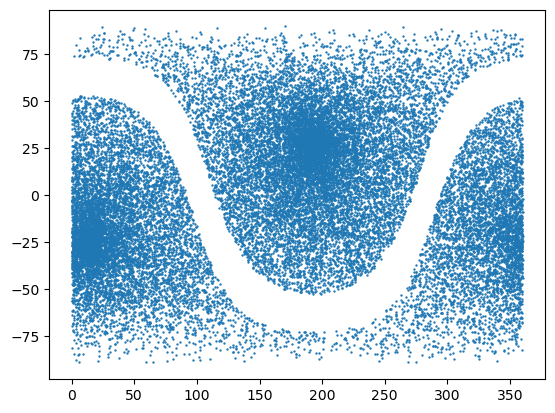

In [5]:
plt.scatter(ra_rands, dec_rands, s = 0.5)

In [6]:
arr = np.empty((len(ra_rands),2))
arr[:, 0] = ra_rands
arr[:, 1] = dec_rands
np.save('new_fsrq_randoms.npy', arr)

In [7]:
ra_rands, dec_rands = create_randoms('bll')

100%|██████████| 461760/461760 [00:34<00:00, 13354.71it/s]


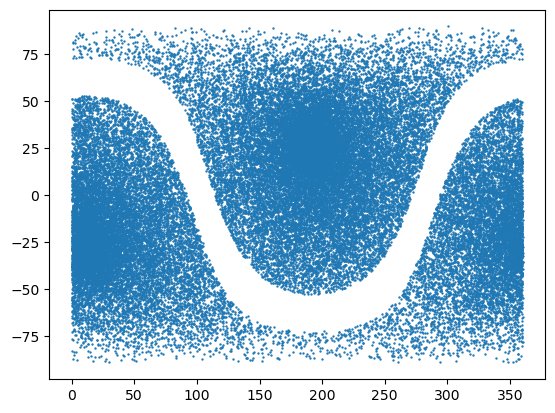

In [8]:
plt.scatter(ra_rands, dec_rands, s = 0.5)

In [9]:
arr = np.empty((len(ra_rands),2))
arr[:, 0] = ra_rands
arr[:, 1] = dec_rands
np.save('new_bll_randoms.npy', arr)

In [35]:
from compute_wtheta import compute_wtheta

In [51]:
theta_bins = np.linspace(0.001, 20, 10)
res_fsrq = compute_wtheta(theta_bins, '4LAC_DR3_FSRQ.fits', 'new_fsrq_randoms.npy')
fsrq_arr = wtheta_dvecs(res_fsrq)

In [52]:
res_bll = compute_wtheta(theta_bins, '4LAC_DR3_BLL.fits', 'new_bll_randoms.npy')
bll_arr = wtheta_dvecs(res_bll)

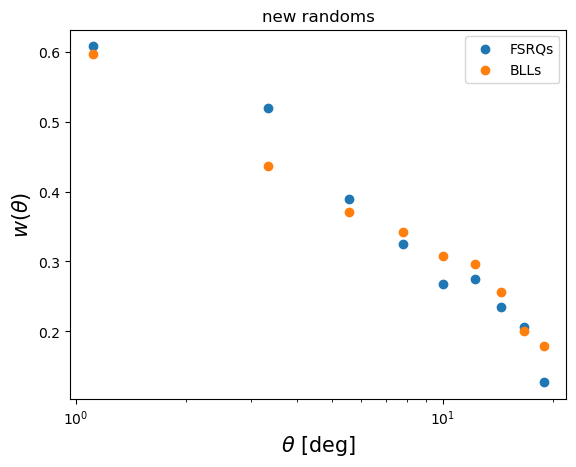

In [53]:
plt.scatter(fsrq_arr[:, 0], fsrq_arr[:, 1], label = 'FSRQs')
#plt.errorbar(fsrq_arr[:, 0], fsrq_arr[:, 1], yerr = fsrq_arr[:, 2], linestyle = '', capsize = 5)
plt.scatter(bll_arr[:, 0], bll_arr[:, 1], label = 'BLLs')
#plt.errorbar(bll_arr[:, 0], bll_arr[:, 1], yerr = bll_arr[:, 2], linestyle = '', capsize = 5)
plt.title('new randoms')
plt.xlabel(r'$\theta$' + ' [deg]', fontsize = 15)
plt.ylabel(r'$w(\theta)$', fontsize = 15)
plt.xscale('log')
plt.legend()

Below, we test the function above to make sure it behaves as expected...

In [67]:
assign_thresh(0, -90)

np.float32(1.0748457e-12)

In [122]:
assign_flux(0, -90)

0
0
1.0748457e-12


np.float32(1.0748457e-12)

In [68]:
assign_thresh(0, 90)

np.float32(1.0053599e-12)

In [123]:
assign_flux(0, 90)

0
480
1.0053599e-12


np.float32(1.0053599e-12)

In [69]:
assign_thresh(360, 90)

np.float32(1.0052548e-12)

In [124]:
assign_flux(360, 90)

959
480
1.0052548e-12


np.float32(1.0052548e-12)

In [70]:
assign_thresh(360, -90)

np.float32(1.0748346e-12)

In [125]:
assign_flux(360, -90)

959
0
1.0748346e-12


np.float32(1.0748346e-12)

In [126]:
# Now, try something near the middle, where the flux threshold is highest, and compare to the cbar
assign_flux(180, 0)

479
240
1.6185872e-11


np.float32(1.6185872e-11)

In [71]:
assign_thresh(180, 0)

np.float32(1.6185872e-11)

Looks good! 

In [11]:
blazar_cat = fits.open('table-4LAC-DR3-h.fits')[1].data
blazar_cat.columns

ColDefs(
    name = 'Source_Name'; format = '18A'
    name = 'DataRelease'; format = 'I'; null = 16959
    name = 'RAJ2000'; format = 'E'; unit = 'deg'; disp = 'F8.4'
    name = 'DEJ2000'; format = 'E'; unit = 'deg'; disp = 'F8.4'
    name = 'GLON'; format = 'E'; unit = 'deg'; disp = 'F8.4'
    name = 'GLAT'; format = 'E'; unit = 'deg'; disp = 'F8.4'
    name = 'Signif_Avg'; format = 'E'; disp = 'F8.3'
    name = 'Flux1000'; format = 'E'; unit = 'ph cm-2 s-1'; disp = 'E10.4'
    name = 'Unc_Flux1000'; format = 'E'; unit = 'ph cm-2 s-1'; disp = 'E10.4'
    name = 'Energy_Flux100'; format = 'E'; unit = 'erg cm-2 s-1'; disp = 'E10.4'
    name = 'Unc_Energy_Flux100'; format = 'E'; unit = 'erg cm-2 s-1'; disp = 'E10.4'
    name = 'SpectrumType'; format = '18A'
    name = 'PL_Index'; format = 'E'; disp = 'F8.4'
    name = 'Unc_PL_Index'; format = 'E'; disp = 'F8.4'
    name = 'Pivot_Energy'; format = 'E'; unit = 'MeV'; disp = 'F10.2'
    name = 'LP_Index'; format = 'E'; disp = 'F8.4'
    nam

In [12]:
blazar_cat = fits.open('table-4LAC-DR3-h.fits')[1].data

def create_randoms(sample): # Should potentially implement multiprocessing depending on size of cat. For now, okay...
    '''
    Only meant for use with FSRQs and BLLs 
    '''
    
    if sample == 'fsrq':
        indices = np.where(blazar_cat['CLASS'] == 'fsrq')[0].tolist() + np.where(blazar_cat['CLASS'] == 'FSRQ')[0].tolist()
        
    if sample == 'bll': 
        indices = np.where(blazar_cat['CLASS'] == 'bll')[0].tolist() + np.where(blazar_cat['CLASS'] == 'BLL')[0].tolist()

    fluxes = blazar_cat['Energy_Flux100'][indices]
    nrands = 0
    rand_pos = np.empty((40 * len(fluxes),3))

    while nrands < 40 * len(fluxes):
        flux = np.random.choice(fluxes, size = 1)
        sin_long = np.random.uniform(-1., 1., 1)
        long = (np.arcsin(sin_long) * 180 / np.pi)[0] 
        
        if abs(long) > 10:
            lat = np.random.uniform(0., 360., 1)[0]
            thresh = assign_thresh(lat, long)

            if flux > thresh: 
                #print('success')
                gal_coords = SkyCoord(l = lat * u.degree, b = long * u.degree, frame = 'galactic')
                dec = gal_coords.icrs.dec.to(u.deg).value
                rand_pos[nrands:, 0] = gal_coords.icrs.ra.to(u.deg).value
                rand_pos[nrands:, 1] = dec
                rand_pos[nrands:, 2] = flux
                nrands += 1

            #else:
            #    print('failed flux') # Just for debugging 

    return rand_pos  

In [13]:
fsrq_rands = create_randoms('fsrq')

In [14]:
np.save('good_fsrq_randoms.npy', fsrq_rands)

In [15]:
bll_rands = create_randoms('bll')

In [16]:
np.save('good_bll_randoms.npy', bll_rands)

None are failing with the fluxes they get... maybe we are using the wrong fluxes? (FIXED)

(0.0, 7.5e-11)

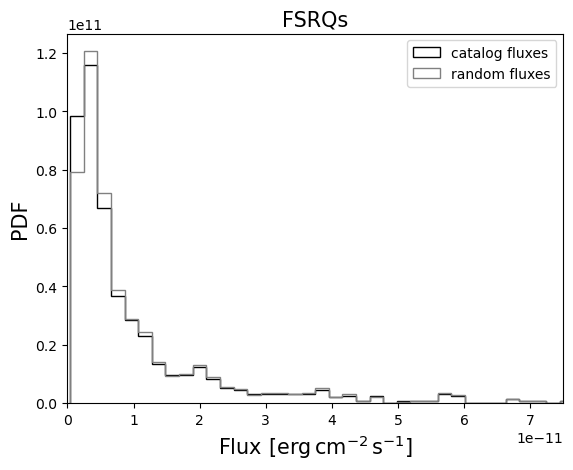

In [19]:
indices = np.where(blazar_cat['CLASS'] == 'fsrq')[0].tolist() + np.where(blazar_cat['CLASS'] == 'FSRQ')[0].tolist()
cat_fluxes = blazar_cat['Energy_Flux100'][indices]

freq, bins, _ = plt.hist(cat_fluxes, bins = 'fd', density = True, color = 'k', histtype = 'step', label = 'catalog fluxes')
plt.hist(fsrq_rands[:, -1], bins = bins, density = True, color = 'grey', histtype = 'step', label = 'random fluxes')
plt.title('FSRQs', fontsize = 15)
plt.xlabel('Flux' + r'$\,\,[\mathrm{erg\,cm^{-2}\,s^{-1}}]$', fontsize = 15)
plt.ylabel('PDF', fontsize = 15)
plt.legend(loc = 'best')
plt.xlim(0, 0.75e-10)

(0.0, 3e-11)

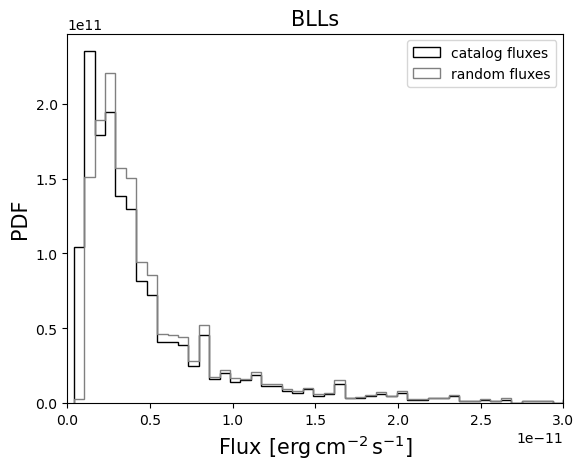

In [23]:
indices = np.where(blazar_cat['CLASS'] == 'bll')[0].tolist() + np.where(blazar_cat['CLASS'] == 'bll')[0].tolist()
cat_fluxes = blazar_cat['Energy_Flux100'][indices]

freq, bins, _ = plt.hist(cat_fluxes, bins = 'fd', density = True, color = 'k', histtype = 'step', label = 'catalog fluxes')
plt.hist(bll_rands[:, -1], bins = bins, density = True, color = 'grey', histtype = 'step', label = 'random fluxes')
plt.title('BLLs', fontsize = 15)
plt.xlabel('Flux' + r'$\,\,[\mathrm{erg\,cm^{-2}\,s^{-1}}]$', fontsize = 15)
plt.ylabel('PDF', fontsize = 15)
plt.legend(loc = 'best')
plt.xlim(0, 3e-11)

(360.0, 0.0)

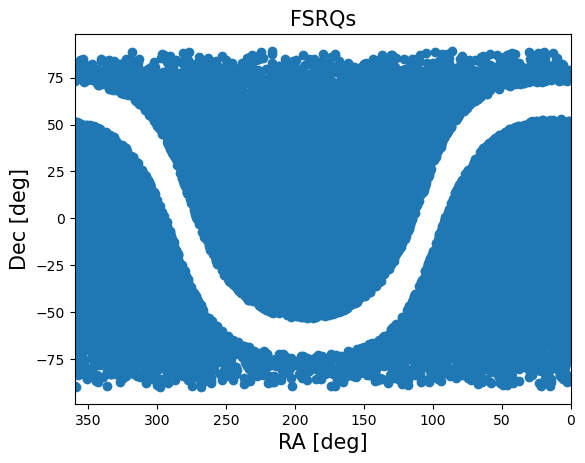

In [24]:
plt.scatter(fsrq_rands[:, 0], fsrq_rands[:, 1])
plt.title('FSRQs', fontsize = 15)
plt.xlabel('RA [deg]', fontsize = 15)
plt.ylabel('Dec [deg]', fontsize = 15)
plt.xlim(360, 0)

(360.0, 0.0)

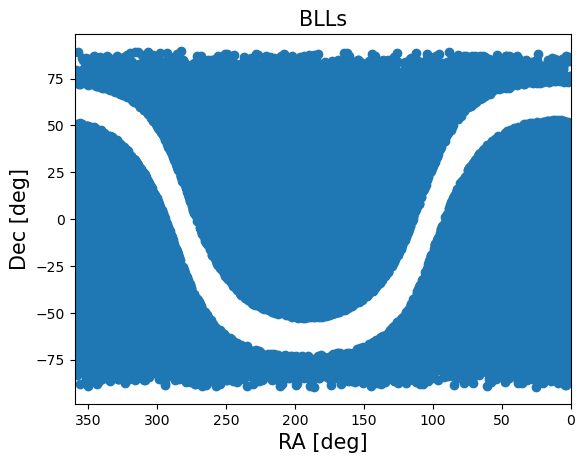

In [25]:
plt.scatter(bll_rands[:, 0], bll_rands[:, 1])
plt.title('BLLs', fontsize = 15)
plt.xlabel('RA [deg]', fontsize = 15)
plt.ylabel('Dec [deg]', fontsize = 15)
plt.xlim(360, 0)

In [2]:
from compute_wtheta import compute_wtheta

In [3]:
new_wtheta_fsrq = compute_wtheta('4LAC_DR3_FSRQ.fits', 'good_fsrq_randoms.npy')

In [4]:
new_wtheta_bll = compute_wtheta('4LAC_DR3_BLL.fits', 'good_bll_randoms.npy')

In [7]:
new_fsrq_arr = wtheta_dvecs(new_wtheta_fsrq)
new_bll_arr = wtheta_dvecs(new_wtheta_bll)

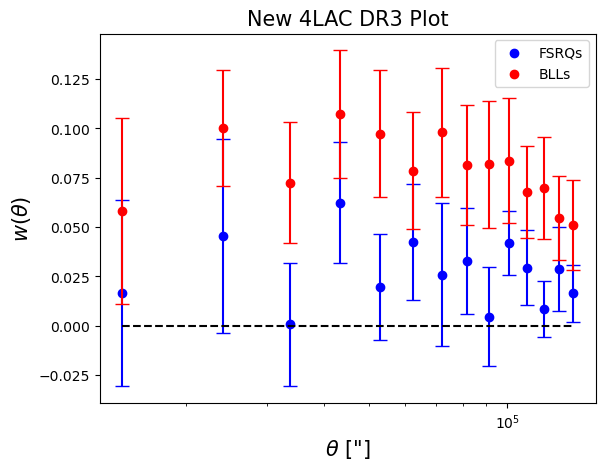

In [8]:
plt.scatter(new_fsrq_arr[:, 0] * 3600, new_fsrq_arr[:, 1], color = 'blue', label = 'FSRQs')
plt.errorbar(new_fsrq_arr[:, 0] * 3600, new_fsrq_arr[:, 1], yerr = new_fsrq_arr[:, 2], linestyle = '', capsize = 5, color = 'blue')
plt.scatter(new_bll_arr[:, 0] * 3600, new_bll_arr[:, 1], color = 'red', label = 'BLLs')
plt.errorbar(new_bll_arr[:, 0] * 3600, new_bll_arr[:, 1], yerr = new_bll_arr[:, 2], linestyle = '', capsize = 5, color = 'red')
plt.hlines(0, min(new_fsrq_arr[:, 0] * 3600), max(new_fsrq_arr[:, 0] * 3600), linestyle = '--', color = 'k')
plt.xscale('log')
plt.title('New 4LAC DR3 Plot', fontsize = 15)
plt.xlabel(r'$\theta$' + ' ["]', fontsize = 15)
plt.ylabel(r'$w(\theta)$', fontsize = 15)
plt.legend(loc = 'best')

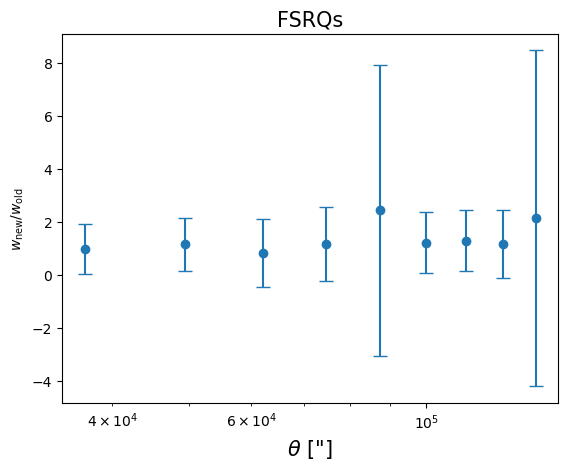

In [23]:
err = abs(new_fsrq_arr[:, 1] / fsrq_arr[:, 1]) * np.sqrt(((new_fsrq_arr[:, -1] / new_fsrq_arr[:, 1]) ** 2) + ((fsrq_arr[:, -1] / fsrq_arr[:, 1]) ** 2))
plt.scatter(new_fsrq_arr[:, 0] * 3600, new_fsrq_arr[:, 1] / fsrq_arr[:, 1])
plt.errorbar(new_fsrq_arr[:, 0] * 3600, new_fsrq_arr[:, 1] / fsrq_arr[:, 1], err, linestyle = '', capsize = 5)
plt.title('FSRQs', fontsize = 15)
plt.ylabel(r'$w_{\mathrm{new}}/w_{\mathrm{old}}$')
plt.xlabel(r'$\theta$' + ' ["]', fontsize = 15)
plt.xscale('log')

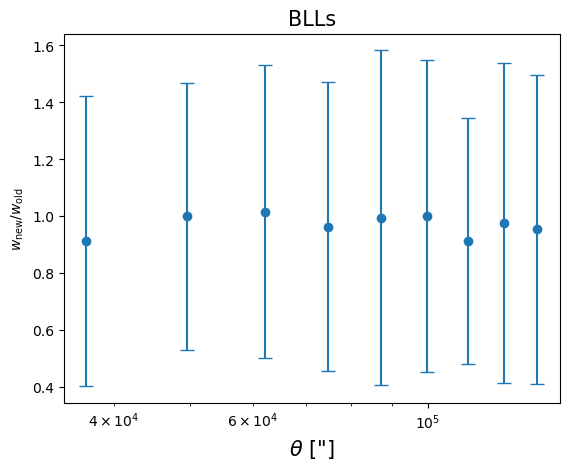

In [24]:
err = abs(new_bll_arr[:, 1] / bll_arr[:, 1]) * np.sqrt(((new_bll_arr[:, -1] / new_bll_arr[:, 1]) ** 2) + ((bll_arr[:, -1] / bll_arr[:, 1]) ** 2))
plt.scatter(new_bll_arr[:, 0] * 3600, new_bll_arr[:, 1] / bll_arr[:, 1])
plt.errorbar(new_bll_arr[:, 0] * 3600, new_bll_arr[:, 1] / bll_arr[:, 1], err, linestyle = '', capsize = 5)
plt.title('BLLs', fontsize = 15)
plt.ylabel(r'$w_{\mathrm{new}}/w_{\mathrm{old}}$')
plt.xlabel(r'$\theta$' + ' ["]', fontsize = 15)
plt.xscale('log')

Now, we want to see which scale maximizes the 2PCF. This scale will set our 'minimum scale'...

In [5]:
new_wtheta_fsrq = compute_wtheta('4LAC_DR3_FSRQ.fits', 'good_fsrq_randoms.npy') # Don't need jackknifing for now

In [6]:
new_wtheta_bll = compute_wtheta('4LAC_DR3_BLL.fits', 'good_bll_randoms.npy')

minimum angular scale for FSRQs: 0.25075158902823136 deg


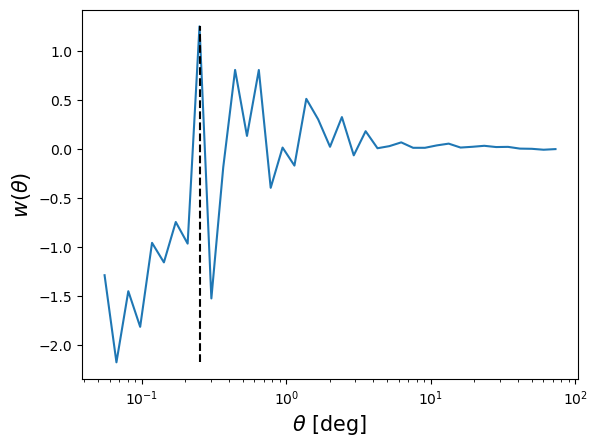

In [53]:
max_idx = np.where(new_wtheta_fsrq.corr == max(new_wtheta_fsrq.corr))[0]
plt.plot(new_wtheta_fsrq.sep, new_wtheta_fsrq.corr)
plt.vlines(new_wtheta_fsrq.sep[max_idx], min(new_wtheta_fsrq.corr), max(new_wtheta_fsrq.corr), color = 'k', linestyle = '--')
plt.xlabel(r'$\theta$' + ' [deg]', fontsize = 15)
plt.ylabel(r'$w(\theta)$', fontsize = 15)
plt.xscale('log')
print('minimum angular scale for FSRQs:', new_wtheta_fsrq.sep[max_idx][0], 'deg')

Therefore, we choose 0.26 for FSRQs

minimum angular scale for BLLs: 0.44229747671525815 deg


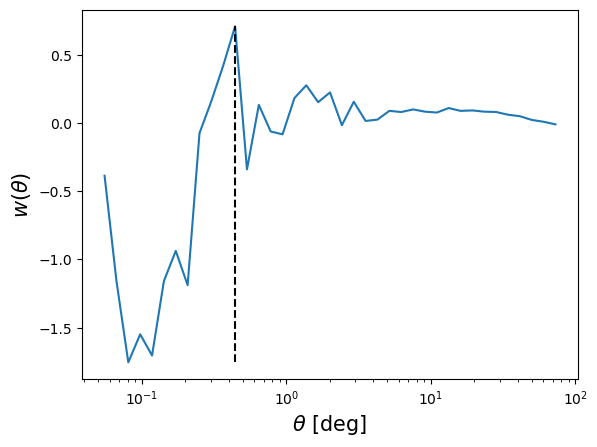

In [7]:
max_idx = np.where(new_wtheta_bll.corr == max(new_wtheta_bll.corr))[0]
plt.plot(new_wtheta_bll.sep, new_wtheta_bll.corr)
plt.vlines(new_wtheta_bll.sep[max_idx], min(new_wtheta_bll.corr), max(new_wtheta_bll.corr), color = 'k', linestyle = '--')
plt.xlabel(r'$\theta$' + ' [deg]', fontsize = 15)
plt.ylabel(r'$w(\theta)$', fontsize = 15)
plt.xscale('log')
print('minimum angular scale for BLLs:', new_wtheta_bll.sep[max_idx][0], 'deg')

Therefore, we choose 0.45 deg for BLLs

Let us test our 'pixelization' code on some blazars to make sure it's working properly

In [126]:
blazars = fits.open('4LAC_DR3_BLL.fits')[1].data
ra_blazars = blazars['ra']
dec_blazars = blazars['dec']
w_blazars = np.arange(len(ra_blazars)) 

ang_scale = 0.45 * np.pi / 180 # 10 degrees
nside_est = 2 ** round(np.log((np.sqrt(np.pi / 3) / ang_scale)) / np.log(2)) # Makes sure the solution is an actual power of 2
nside = int(2 ** ((int(np.log(nside_est) / np.log(2))) + 1)) # Go to slightly higher res than what you think you need
pix = hp.pixelfunc.ang2pix(nside, ra_blazars, dec_blazars, lonlat = True)
blazar_pixels = np.unique(pix)
new_ra_blazars, new_dec_blazars = hp.pixelfunc.pix2ang(nside, blazar_pixels, lonlat = True)
counts = np.bincount(pix, weights = w_blazars) 
new_w_blazars = counts[blazar_pixels]

rands = np.load('good_bll_randoms.npy')
ra_rands = rands[:, 0]
dec_rands = rands[:, 1]
w_rands = np.arange(len(ra_rands))

pix_ = hp.pixelfunc.ang2pix(nside, ra_rands, dec_rands, lonlat = True)
rand_pixels = np.unique(pix_)
new_ra_rands, new_dec_rands = hp.pixelfunc.pix2ang(nside, rand_pixels, lonlat = True)
counts_ = np.bincount(pix_, weights = w_rands)
new_w_rands = counts_[rand_pixels]

In [127]:
theta_bins = np.logspace(np.log10(0.05), np.log10(80), num = 40)
res = pycorr.TwoPointCorrelationFunction('theta', theta_bins, [new_ra_blazars, new_dec_blazars], randoms_positions1 = [new_ra_rands, new_dec_rands], data_weights1 = new_w_blazars, randoms_weights1 = new_w_rands, estimator = 'landyszalay', bin_type = 'custom', position_type = 'rd', compute_sepsavg = False, nthreads = 1)

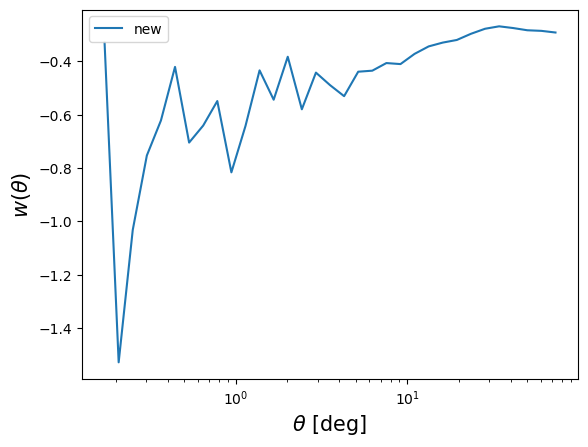

In [128]:
plt.plot(res.sep, res.corr, label = 'new')
#plt.plot(new_wtheta_bll.sep, new_wtheta_bll.corr, label = 'old')
plt.xlabel(r'$\theta$' + ' [deg]', fontsize = 15)
plt.ylabel(r'$w(\theta)$', fontsize = 15)
plt.xscale('log')
plt.legend()

Seems okay... definitely within the large errorbars. 

In [2]:
fsrq_desi_obj = np.load('fsrq_desi_obj.npy', allow_pickle = True).ravel()[0]
bll_desi_obj = np.load('bll_desi_obj.npy', allow_pickle = True).ravel()[0]
dict_ = {'FSRQ':fsrq_desi_obj, 'BLL':bll_desi_obj}

In [6]:
def natural(pycorr_obj):
    nonzero = pycorr_obj.D1R2.wcounts != 0
    corr = np.empty_like(pycorr_obj.D1R2.wcounts, dtype = 'f8')
    corr[...] = np.nan
    D1D2 = pycorr_obj.D1D2.normalized_wcounts()
    D1R2 = pycorr_obj.D1R2.normalized_wcounts() 
    tmp = (D1D2 / D1R2) - 1
    corr[nonzero] = tmp[...]

    return corr 

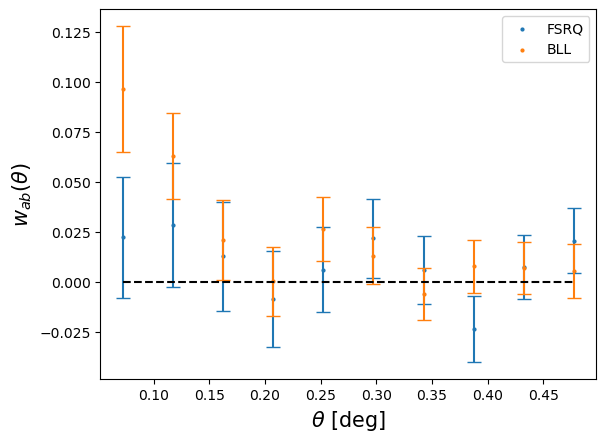

In [4]:
for label, obj in zip(dict_.keys(), dict_.values()):
    wtheta_cross = natural(obj)
    dvecs = []

    for i in obj.realizations:
        try:
            dvecs.append(natural(obj.realization(i)))

        except KeyError: # One jackknife patch is not returning results...
            pass

    cov = np.cov(dvecs, rowvar = False, bias = True) * (len(obj.realizations) - 1)
    err = np.sqrt(cov.diagonal())

    plt.scatter(obj.sep, wtheta_cross, label = label, s = 4)
    plt.errorbar(obj.sep, wtheta_cross, yerr = err, linestyle = '', capsize = 5)
    plt.xlabel(r'$\theta$' + ' [deg]', fontsize = 15)
    plt.ylabel(r'$w_{ab}(\theta)$', fontsize = 15)
    plt.legend(loc = 'best')

plt.hlines(0, min(obj.sep), max(obj.sep), color = 'k', linestyle = '--')
#plt.savefig('blazar_cross_desi.png', dpi = 400, bbox_inches = 'tight')

It is unclear whether the signal above should be consistent with zero. As a second benchmark, we test the pixelization code on DESI galaxies as well 

In [55]:
approx = np.load('approx.npy', allow_pickle = True).ravel()[0]
bench = np.load('bench.npy', allow_pickle = True).ravel()[0]
approx_arr = wtheta_dvecs(approx)
bench_arr = wtheta_dvecs(bench)

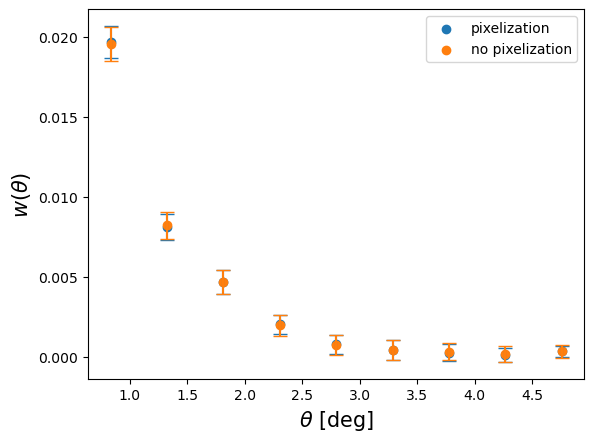

In [59]:
plt.scatter(approx_arr[:, 0], approx_arr[:, 1], label = 'pixelization')
plt.errorbar(approx_arr[:, 0], approx_arr[:, 1], yerr = approx_arr[:, 2], linestyle = '', capsize = 5)
plt.scatter(bench_arr[:, 0], bench_arr[:, 1], label = 'no pixelization')
plt.errorbar(bench_arr[:, 0], bench_arr[:, 1], yerr = bench_arr[:, 2], linestyle = '', capsize = 5)
plt.xlabel(r'$\theta$' + ' [deg]', fontsize = 15)
plt.ylabel(r'$w(\theta)$', fontsize = 15)
plt.legend(loc = 'best')
plt.savefig('test.png', dpi = 400, bbox_inches = 'tight')

The JK errors are quite large for the cross-correlation. This is probably due to our jackknife patches. Let's test this! 

In [3]:
patches = np.load('fsrq_patches.npy')

(360.0, 0.0)

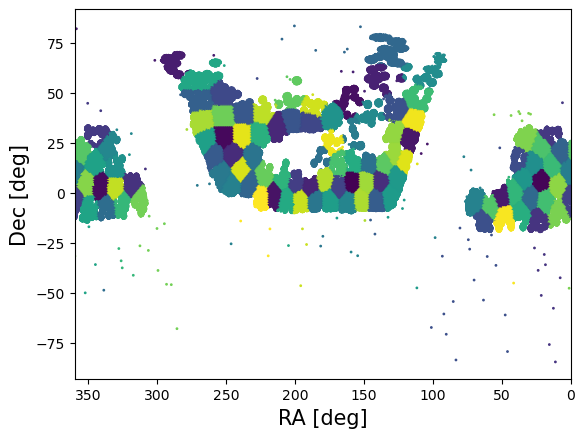

In [7]:
plt.scatter(patches[:, 0][::4], patches[:, 1][::4], c = patches[:, 2][::4], s = 1)
plt.xlabel('RA [deg]', fontsize = 15)
plt.ylabel('Dec [deg]', fontsize = 15)
plt.xlim(360, 0)

We should probably apply a survey mask... But a very coarse one. Let's play around with healpy

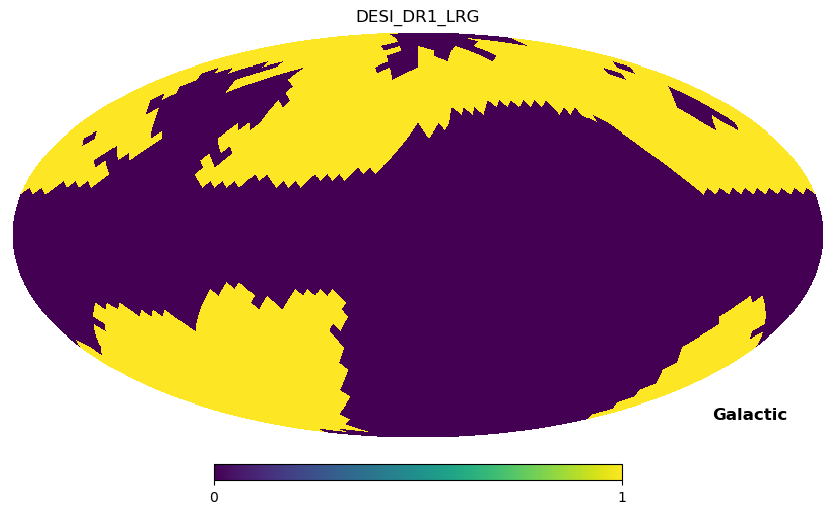

In [12]:
sky_plotter('DESI_DR1_LRG.fits', 16)

That seems good enough for our purposes. Let's now see if we can reduce our errorbars. We may also have to carefully think about the number of jackknife patches. If there are too many, there will be so few blazars in a given patch. 

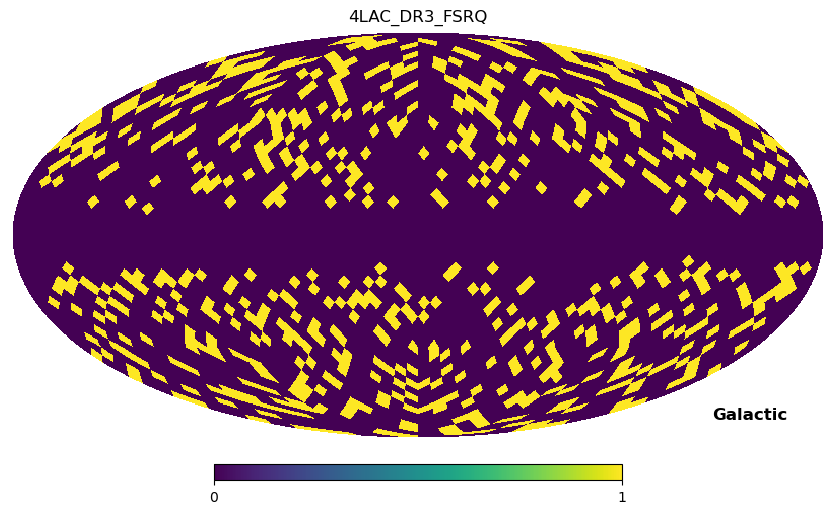

In [13]:
sky_plotter('4LAC_DR3_FSRQ.fits', 16)

Using a mask did not seem to change the size of the errorbars much...

In [84]:
z_bins = {'z1':[0.4, 0.6], 'z2':[0.6, 0.8], 'z3':[0.8, 1], 'z4':[1, 1.2], 'z5':[1.2, 1.4], 'z6':[1.4, 1.6]}
c = plt.cm.vanimo(np.linspace(0, 1, len(z_bins)))

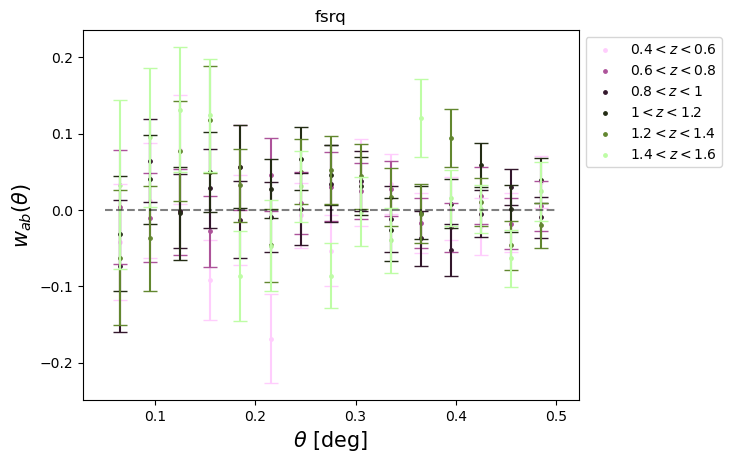

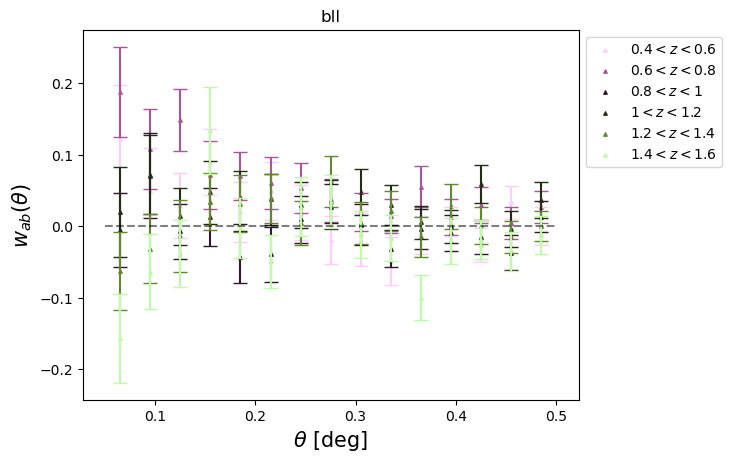

In [32]:
for sample, marker in zip(['fsrq', 'bll'], ['o', '^']):
    for i, z_bin in enumerate(z_bins.keys()):
        f = sample + '_desi_' + str(z_bin) + '.npy'
        obj = np.load(f, allow_pickle = True).ravel()[0]

        wtheta_cross = natural(obj)
        dvecs = []

        for j in obj.realizations:
            try:
                dvecs.append(natural(obj.realization(j)))

            except KeyError: 
                pass

        cov = np.cov(dvecs, rowvar = False, bias = True) * (len(obj.realizations) - 1)
        err = np.sqrt(cov.diagonal())
    
        plt.plot(obj.sep, wtheta_cross, label = str(z_bins[z_bin][0]) + r'$<z<$' + str(z_bins[z_bin][1]), color = c[i])
        plt.errorbar(obj.sep, wtheta_cross, yerr = err, linestyle = '', capsize = 5, color = c[i])
    plt.title(sample)
    plt.hlines(0, 0.05, 0.5, color = 'k', linestyle = '--', alpha = 0.5)
    plt.xlabel(r'$\theta$' + ' [deg]', fontsize = 15)
    plt.ylabel(r'$w_{ab}(\theta)$', fontsize = 15)
    plt.legend(bbox_to_anchor = (1, 1))
    plt.show()

FSRQ median redshift: 1.113


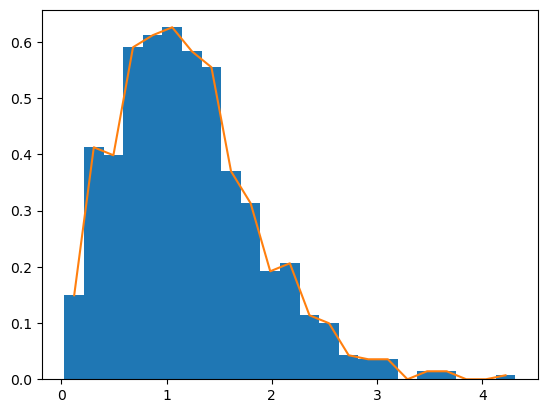

In [86]:
blazar_data = fits.open('table-4LAC-DR3-h.fits')[1].data
indices = np.where(blazar_data['CLASS'] == 'fsrq')[0].tolist() + np.where(blazar_data['CLASS'] == 'FSRQ')[0].tolist()
print('FSRQ median redshift:', np.median(blazar_data['Redshift'][indices]))
fsrq_nz, fsrq_zbins, _ = plt.hist(blazar_data['Redshift'][indices], bins = 'fd', density = True) 
fsrq_z = (fsrq_zbins[1:] + fsrq_zbins[:-1]) / 2
fsrq_dz = fsrq_zbins[1] - fsrq_zbins[0]
plt.plot(fsrq_z, fsrq_nz)

In [109]:
np.sum(fsrq_nz * fsrq_dz)

np.float64(1.0000000109801452)

BLL median redshift: 0.317


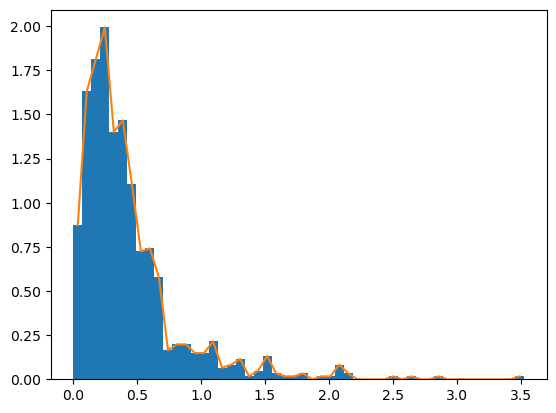

In [87]:
indices_ = np.where(blazar_data['CLASS'] == 'bll')[0].tolist() + np.where(blazar_data['CLASS'] == 'BLL')[0].tolist()
indices__ = np.where((blazar_data['Redshift'][indices_] != np.inf) & (blazar_data['Redshift'][indices_] != -np.inf))
print('BLL median redshift:', np.median(blazar_data['Redshift'][indices_][indices__]))
bll_nz, bll_zbins, __ = plt.hist(blazar_data['Redshift'][indices_][indices__], bins = 'fd', density = True) 
bll_z = (bll_zbins[1:] + bll_zbins[:-1]) / 2
bll_dz = bll_zbins[1] - bll_zbins[0]
plt.plot(bll_z, bll_nz)

In [110]:
np.sum(bll_nz * bll_dz)

np.float64(1.0000000573090009)

In [14]:
cosmo = pyccl.Cosmology(Omega_c = Planck18.Odm0, Omega_b = Planck18.Ob0, h = Planck18.h, A_s =  2.105e-9, n_s = 0.9665)
a_fsrq = 1 / (1 + 1.113)
a_bll = 1 / (1 + 0.149472)
chi_fsrq = pyccl.comoving_radial_distance(cosmo, a_fsrq) * u.Mpc
chi_bll = pyccl.comoving_radial_distance(cosmo, a_bll) * u.Mpc
theta_fsrq = (np.linspace(10, 70, 10) / chi_fsrq.value) * 180 / np.pi # Converts rp into theta 
theta_bll = (np.linspace(10, 70, 10) / chi_bll.value) * 180 / np.pi

In [103]:
from compute_wtheta import compute_wtheta
res_fsrq = compute_wtheta(theta_fsrq, '4LAC_DR3_FSRQ.fits', 'new_fsrq_randoms.npy')
fsrq_arr = wtheta_dvecs(res_fsrq)

In [104]:
res_bll = compute_wtheta(theta_bll, '4LAC_DR3_BLL.fits', 'new_bll_randoms.npy')
bll_arr = wtheta_dvecs(res_bll)

In [12]:
ells = np.arange(1, 4000, 1)

def xi_mm(theta, zs, nz, dz):
    C_integrand = np.empty((len(ells),len(zs)))

    for i, z in enumerate(zs):
        a = 1 / (1 + z)
        chi = pyccl.comoving_radial_distance(cosmo, a) * u.Mpc
        prefact = ((Planck18.H0 * pyccl.background.h_over_h0(cosmo, a = a) / const.c / (chi ** 2)).to(u.Mpc ** -3)).value

        for j, ell in enumerate(ells):
            C_integrand[j, i] = pyccl.power.nonlin_power(cosmo, k = (ell + 0.5) / chi.value, a = a, p_of_k_a = 'delta_matter:delta_matter')

        C_integrand[:, i] *= prefact

    C = np.sum(dz * (nz ** 2) * C_integrand, axis = 1)

    return pyccl.correlations.correlation(cosmo, ell = ells, C_ell = C, theta = theta, type = 'NN', method = 'Legendre')

In [106]:
xi_mm_fsrq = xi_mm(fsrq_arr[:, 0], fsrq_z, fsrq_nz, fsrq_dz) 
xi_mm_bll = xi_mm(bll_arr[:, 0], bll_z, bll_nz, bll_dz) 

Computation of $w(\theta)$:

$w(\theta)\,=\,\sum_{\ell}\frac{2\ell\,+\,1}{4\pi}\int dzn^2(z)b^2\frac{H(z)}{c\chi^2(z)}P_{\mathrm{mm}}\left(\frac{\ell\,+\,1/2}{\chi(z)},\,z\right)\mathcal{L}_{\ell}(\mathrm{cos}\theta)$

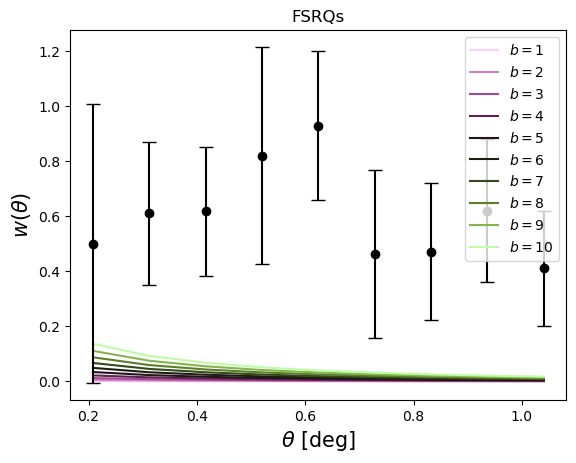

In [107]:
c = plt.cm.vanimo(np.linspace(0, 1, 10))

for i, b in enumerate(range(1, 11)):
    wtheta = (b ** 2) * xi_mm_fsrq
    plt.plot(fsrq_arr[:, 0], wtheta, color = c[i], label = r'$b=$' + str(b))

plt.title('FSRQs')
plt.scatter(fsrq_arr[:, 0], fsrq_arr[:, 1], c = 'k')
plt.errorbar(fsrq_arr[:, 0], fsrq_arr[:, 1], yerr = fsrq_arr[:, 2], linestyle = '', capsize = 5, color = 'k')
plt.xlabel(r'$\theta$' + ' [deg]', fontsize = 15)
plt.ylabel(r'$w(\theta)$', fontsize = 15)
plt.legend(loc = 'upper right')

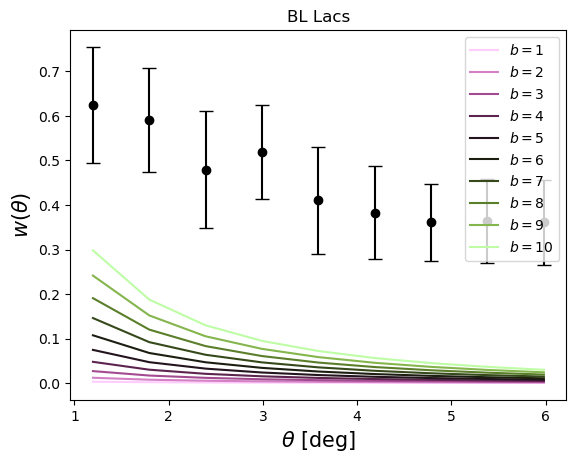

In [108]:
for i, b in enumerate(range(1, 11)):
    wtheta = (b ** 2) * xi_mm_bll
    plt.plot(bll_arr[:, 0], wtheta, color = c[i], label = r'$b=$' + str(b))

plt.title('BL Lacs')
plt.scatter(bll_arr[:, 0], bll_arr[:, 1], color = 'k')
plt.errorbar(bll_arr[:, 0], bll_arr[:, 1], yerr = bll_arr[:, 2], linestyle = '', capsize = 5, color = 'k')
plt.xlabel(r'$\theta$' + ' [deg]', fontsize = 15)
plt.ylabel(r'$w(\theta)$', fontsize = 15)
plt.legend(loc = 'upper right')

In [72]:
z_bins = {'z1':[0.4, 0.7], 'z2':[0.7, 1.], 'z3':[1., 1.3], 'z4':[1.3, 1.6]}

bias for redshift bin [0.4, 0.7] : 1.9196852573453096
bias for redshift bin [0.7, 1.0] : 2.1178937109121447
bias for redshift bin [1.0, 1.3] : 1.3549270296169456
bias for redshift bin [1.3, 1.6] : 1.53701891751536


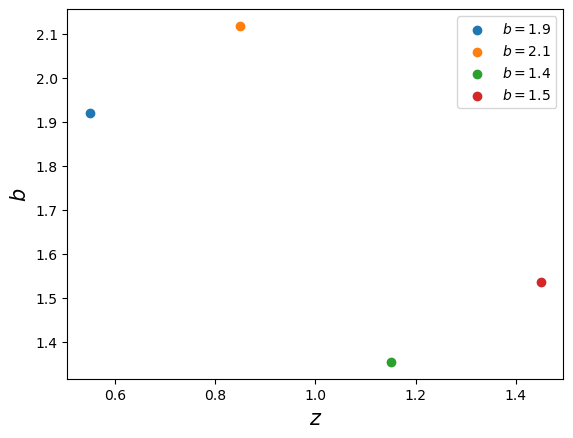

In [64]:
for z_bin in ['z1', 'z2', 'z3', 'z4']:
    obj = np.load('desi_' + z_bin + '.npy', allow_pickle = True).ravel()[0]
    res, cov = wtheta_dvecs(obj, return_corrected_cov = True)
    inv_cov = np.linalg.inv(cov)
    z_arr = np.load('desi_n_' + z_bin + '.npy')
    zs = z_arr[:, 0]
    nz = z_arr[:, 1]
    dz = zs[1] - zs[0]
    C_integrand = np.empty((len(ells),len(zs)))

    for i, z in enumerate(zs):
        a = 1 / (1 + z)
        chi = pyccl.comoving_radial_distance(cosmo, a) * u.Mpc
        prefact = ((Planck18.H0 * pyccl.background.h_over_h0(cosmo, a = a) / const.c / (chi ** 2)).to(u.Mpc ** -3)).value

        for j, ell in enumerate(ells):
            C_integrand[j, i] = pyccl.power.nonlin_power(cosmo, k = (ell + 0.5) / chi.value, a = a, p_of_k_a = 'delta_matter:delta_matter')

        C_integrand[:, i] *= prefact

    C = np.sum(dz * (nz ** 2) * C_integrand, axis = 1)
    w_dm = pyccl.correlations.correlation(cosmo, ell = ells, C_ell = C, theta = res[:, 0], type = 'NN', method = 'Legendre')

    def chi_sq(b):
        wtheta_theory = (b ** 2) * w_dm 
        delta = wtheta_theory - res[:, 1]
        return np.matmul(delta, np.matmul(inv_cov, delta)) 

    minimize_res = minimize(chi_sq, [2.])
    b = minimize_res.x[0]
    print('bias for redshift bin', z_bins[z_bin], ':', b)
    plt.scatter((z_bins[z_bin][0] + z_bins[z_bin][1]) / 2, b, label = r'$b=$' + str(round(b, 1)))

plt.xlabel(r'$z$', fontsize = 15)
plt.ylabel(r'$b$', fontsize = 15)
plt.legend(loc = 'upper right')

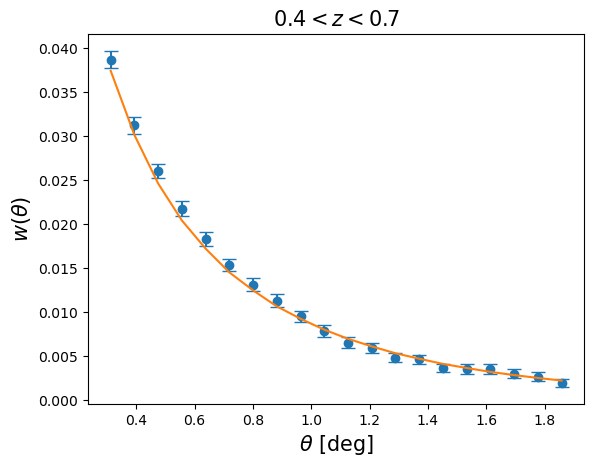

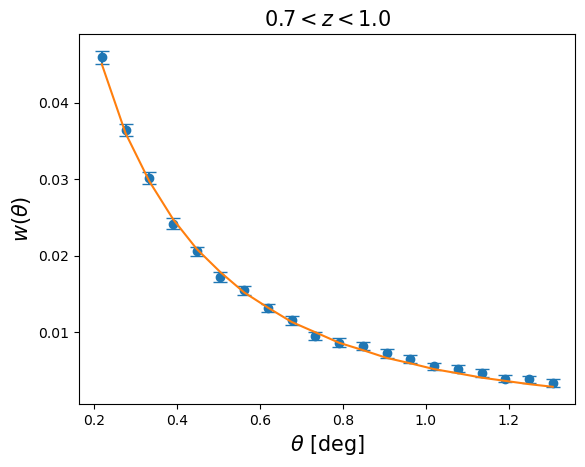

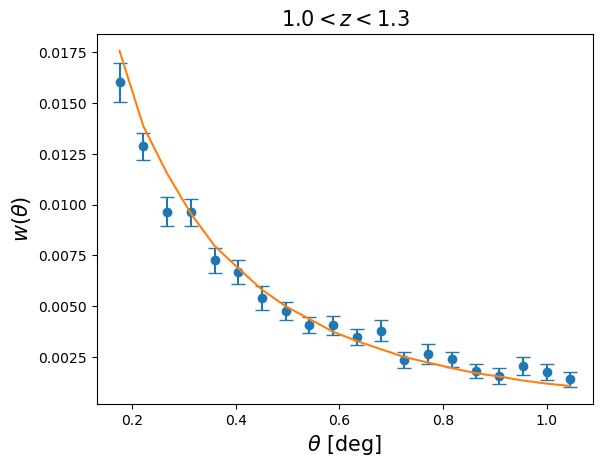

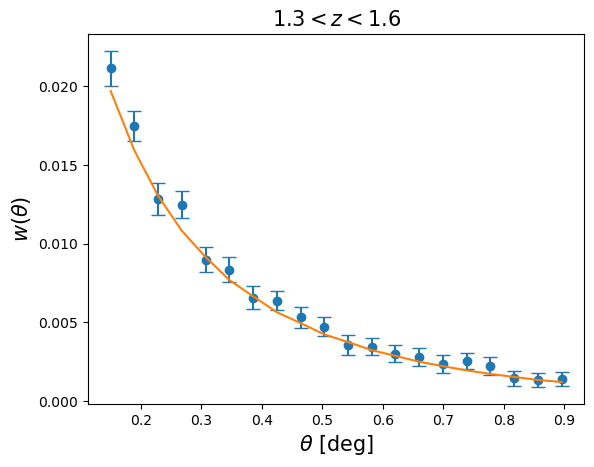

In [79]:
for zbin, b in zip(['z1', 'z2', 'z3', 'z4'], [1.9, 2.1, 1.4, 1.5]):
    obj = np.load('desi_' + zbin + '.npy', allow_pickle = True).ravel()[0]
    res = wtheta_dvecs(obj, return_corrected_cov = False)
    z_arr = np.load('desi_n_' + zbin + '.npy')
    zs = z_arr[:, 0]
    nz = z_arr[:, 1]
    dz = zs[1] - zs[0]
    w_dm = xi_mm(res[:, 0], zs, nz, dz)

    plt.scatter(res[:, 0], res[:, 1])
    plt.errorbar(res[:, 0], res[:, 1], yerr = res[:, 2], linestyle = '', capsize = 5)
    plt.plot(res[:, 0], w_dm * (b ** 2))
    plt.title(str(z_bins[zbin][0]) + r'$<z<$' + str(z_bins[zbin][1]), fontsize = 15)
    plt.xlabel(r'$\theta\,\,[\mathrm{deg}]$', fontsize = 15)
    plt.ylabel(r'$w(\theta)$', fontsize = 15)
    plt.show()

Given that no reasonable biases can reproduce the amplitudes of our signals, we can assume that our randoms are innaccurate. 

In [143]:
def w_z(sample, z_bin, alpha):
    mid_z = (z_bins[z_bin][1] + z_bins[z_bin][0]) / 2
    f = sample + '_desi_' + str(z_bin) + '.npy'
    obj = np.load(f, allow_pickle = True).ravel()[0]
    wtheta_cross = natural(obj)
    D = ((mid_z * cu.redshift).to(u.Mpc, cu.redshift_distance(Planck18, kind = 'comoving'))).value * Planck18.h
    approx_rp = np.radians(obj.sep) * D 
    indices_to_keep = np.where((approx_rp >= 1.5) & (approx_rp <= 5))[0]
    wtheta_cross = wtheta_cross[indices_to_keep]
    theta = obj.sep[indices_to_keep]
    dtheta = obj.sep[1] - obj.sep[0]
    num = np.sum(dtheta * (theta ** alpha) * wtheta_cross)
    denom = np.sum(dtheta * (theta ** alpha))

    dvecs = []

    for i in obj.realizations:
        wtheta_cross_ = natural(obj.realization(i))[indices_to_keep]
        num_ = np.sum(dtheta * (theta ** alpha) * wtheta_cross_)
        dvecs.append(num_ / denom)

    cov = np.cov(dvecs, rowvar = False, bias = True) * (len(obj.realizations) - 1)
    err = np.sqrt(cov)

    return mid_z, num / denom, err 

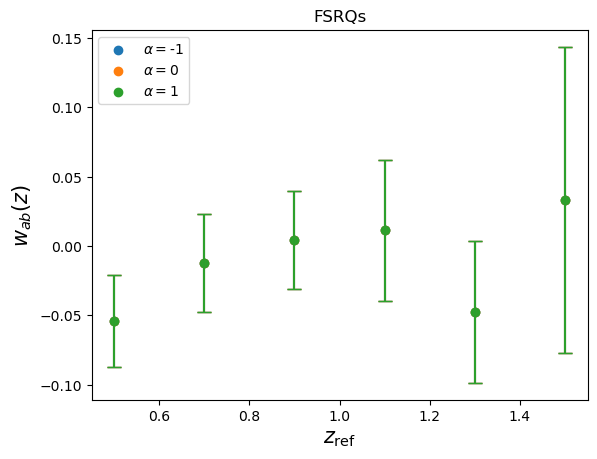

In [144]:
for alpha in [-1, 0, 1]:
    res = np.empty((len(z_bins),3))

    for i, z_bin in enumerate(z_bins.keys()):
        x, y, z = w_z('fsrq', z_bin, 1)
        res[i, 0] = x
        res[i, 1] = y
        res[i, 2] = z

    plt.scatter(res[:, 0], res[:, 1], label = r'$\alpha=$' + str(alpha))
    plt.errorbar(res[:, 0], res[:, 1], yerr = res[:, 2], linestyle = '', capsize = 5)

plt.title('FSRQs')
plt.xlabel(r'$z_{\mathrm{ref}}$', fontsize = 15)
plt.ylabel(r'$w_{ab}(z)$', fontsize = 15)
plt.legend(loc = 'best')

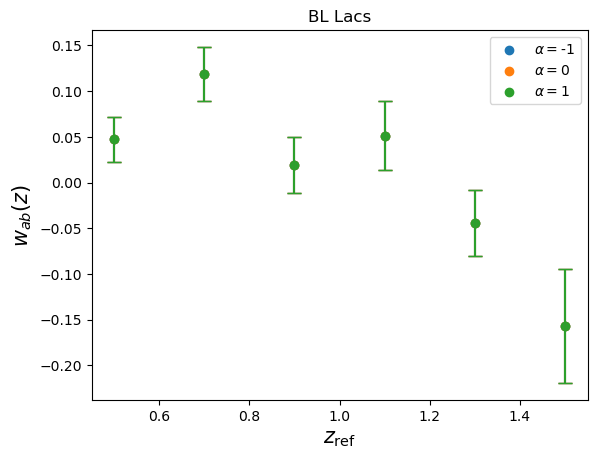

In [146]:
for alpha in [-1, 0, 1]:
    res = np.empty((len(z_bins),3))

    for i, z_bin in enumerate(z_bins.keys()):
        x, y, z = w_z('bll', z_bin, 1)
        res[i, 0] = x
        res[i, 1] = y
        res[i, 2] = z

    plt.scatter(res[:, 0], res[:, 1], label = r'$\alpha=$' + str(alpha))
    plt.errorbar(res[:, 0], res[:, 1], yerr = res[:, 2], linestyle = '', capsize = 5)

plt.title('BL Lacs')
plt.xlabel(r'$z_{\mathrm{ref}}$', fontsize = 15)
plt.ylabel(r'$w_{ab}(z)$', fontsize = 15)
plt.legend(loc = 'best')

Try plotting the above with some improvements (masking, larger redshift bins, more intentional angular scales)...

In [2]:
z_bins = {'z0':[0.1, 0.4], 'z1':[0.4, 0.7], 'z2':[0.7, 1.], 'z3':[1., 1.3], 'z4':[1.3, 1.6]}

In [10]:
def w_z(sample, z_bin, alpha):
    mid_z = (z_bins[z_bin][1] + z_bins[z_bin][0]) / 2
    f = sample + '_desi_' + str(z_bin) + '.npy'
    obj = np.load(f, allow_pickle = True).ravel()[0] 
    wtheta_cross = natural(obj)
    theta = obj.sep # Don't need any theta cuts... scales are already optimized
    dtheta = theta[1] - theta[0]
    num = np.sum(dtheta * (theta ** alpha) * wtheta_cross)
    denom = np.sum(dtheta * (theta ** alpha))

    dvecs = []

    for i in obj.realizations:
        wtheta_cross_ = natural(obj.realization(i))
        num_ = np.sum(dtheta * (theta ** alpha) * wtheta_cross_)
        dvecs.append(num_ / denom)

    cov = np.cov(dvecs, rowvar = False, bias = True) * (len(obj.realizations) - 1)
    err = np.sqrt(cov)

    return theta, mid_z, num / denom, err 

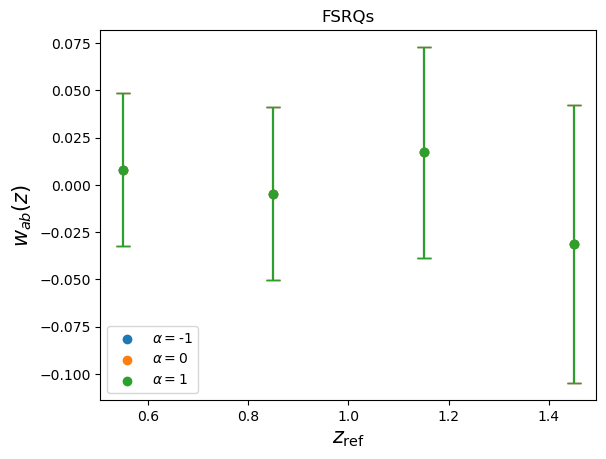

In [22]:
for alpha in [-1, 0, 1]:
    res = np.empty((len(z_bins),3))

    for i, z_bin in enumerate(z_bins.keys()):
        x, y, z = w_z('fsrq', z_bin, 1)
        res[i, 0] = x
        res[i, 1] = y
        res[i, 2] = z

    plt.scatter(res[:, 0], res[:, 1], label = r'$\alpha=$' + str(alpha))
    plt.errorbar(res[:, 0], res[:, 1], yerr = res[:, 2], linestyle = '', capsize = 5)

plt.hlines(0, min(res[:, 0]), max(res[:, 0]), color = 'grey', linestyle = '--')
plt.title('FSRQs')
plt.xlabel(r'$z_{\mathrm{ref}}$', fontsize = 15)
plt.ylabel(r'$w_{ab}(z)$', fontsize = 15)
plt.legend(loc = 'best')

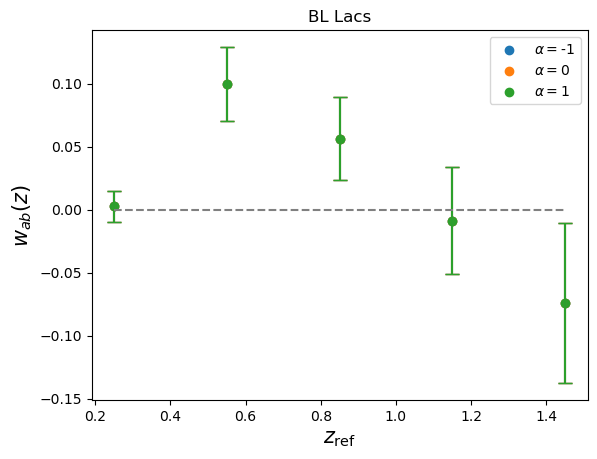

In [7]:
for alpha in [-1, 0, 1]:
    res = np.empty((len(z_bins),3))

    for i, z_bin in enumerate(z_bins.keys()):
        x, y, z = w_z('bll', z_bin, 1)
        res[i, 0] = x
        res[i, 1] = y
        res[i, 2] = z

    plt.scatter(res[:, 0], res[:, 1], label = r'$\alpha=$' + str(alpha))
    plt.errorbar(res[:, 0], res[:, 1], yerr = res[:, 2], linestyle = '', capsize = 5)

plt.hlines(0, min(res[:, 0]), max(res[:, 0]), color = 'grey', linestyle = '--')
plt.title('BL Lacs')
plt.xlabel(r'$z_{\mathrm{ref}}$', fontsize = 15)
plt.ylabel(r'$w_{ab}(z)$', fontsize = 15)
plt.legend(loc = 'best')

In [88]:
bzs = {'z1':1.9, 'z2':2.1, 'z3':1.4, 'z4':1.5}
cosmo = pyccl.Cosmology(Omega_c = Planck18.Odm0, Omega_b = Planck18.Ob0, h = Planck18.h, A_s =  2.105e-9, n_s = 0.9665)
ells = np.arange(1, 4000, 1)

def compute_nz(sample):
    nz = np.empty((len(bzs.keys()),))
    zs = np.empty(nz.shape)
    err = np.empty(nz.shape)
    for idx, z_bin in enumerate(bzs.keys()): 
        theta, mid_z, wz, wz_err = w_z(sample, z_bin, 0) # Angle averaged 
        zs[idx] = mid_z
        dtheta = theta[1] - theta[0]
        b = bzs[z_bin]
        spec_z_arr = np.load('desi_n_' + z_bin + '.npy')
        spec_zs = spec_z_arr[:, 0]
        spec_nz = spec_z_arr[:, 1]
        spec_dz = spec_zs[1] - spec_zs[0]
        C_integrand = np.empty((len(ells),len(spec_zs)))

        for i, z in enumerate(spec_zs):
            a = 1 / (1 + z)
            chi = pyccl.comoving_radial_distance(cosmo, a) * u.Mpc
            prefact = ((Planck18.H0 * pyccl.background.h_over_h0(cosmo, a = a) / const.c / (chi ** 2)).to(u.Mpc ** -3)).value

            for j, ell in enumerate(ells):
                C_integrand[j, i] = pyccl.power.nonlin_power(cosmo, k = (ell + 0.5) / chi.value, a = a, p_of_k_a = 'delta_matter:delta_matter')

            C_integrand[:, i] *= prefact

        C = np.sum(spec_dz * C_integrand, axis = 1)
        w_dm_theta = pyccl.correlations.correlation(cosmo, ell = ells, C_ell = C, theta = theta, type = 'NN', method = 'Legendre')
        num = np.sum(dtheta * (theta ** alpha) * w_dm_theta)
        denom = np.sum(dtheta * (theta ** alpha)) 
        w_dm_z = num / denom
        nz[idx] = wz / (b * w_dm_z) 
        err[idx] = abs(wz / (b * w_dm_z)) * wz_err / abs(wz)

    corrected_nz = np.where(nz < 0, 0, nz)
    corrected_nz /= np.sum(corrected_nz * 0.3)
    return zs, corrected_nz, err

In [89]:
zs, bll_nz, bll_err = compute_nz('bll')

Text(0, 0.5, '$n(z)$')

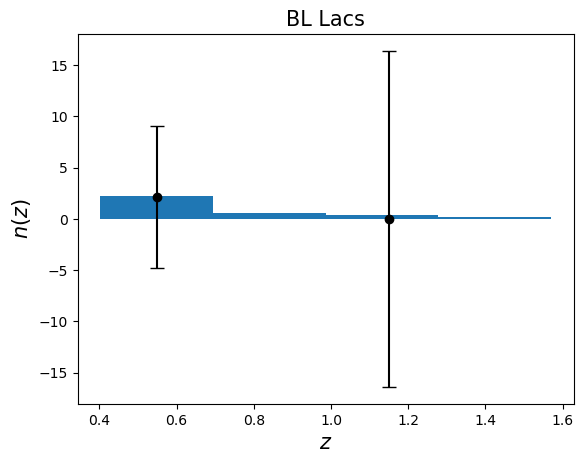

In [90]:
plt.scatter(zs[::2], bll_nz[::2], color = 'k', zorder = 2)
plt.errorbar(zs[::2], bll_nz[::2], yerr = bll_err[::2], color = 'k', linestyle = '', capsize = 5, zorder = 3)
blazar_data = fits.open('table-4LAC-DR3-h.fits')[1].data
indices_ = np.where(blazar_data['CLASS'] == 'bll')[0].tolist() + np.where(blazar_data['CLASS'] == 'BLL')[0].tolist()
indices__ = np.where(((blazar_data['Redshift'][indices_] != np.inf) & (blazar_data['Redshift'][indices_] != -np.inf)) & ((blazar_data['Redshift'][indices_] > 0.4) & (blazar_data['Redshift'][indices_] < 1.6)))
plt.hist(blazar_data['Redshift'][indices_][indices__], bins = 4, density = True) 
plt.title('BL Lacs', fontsize = 15)
plt.xlabel(r'$z$', fontsize = 15)
plt.ylabel(r'$n(z)$', fontsize = 15)

In [91]:
zs, fsrq_nz, fsrq_err = compute_nz('fsrq')

Text(0, 0.5, '$n(z)$')

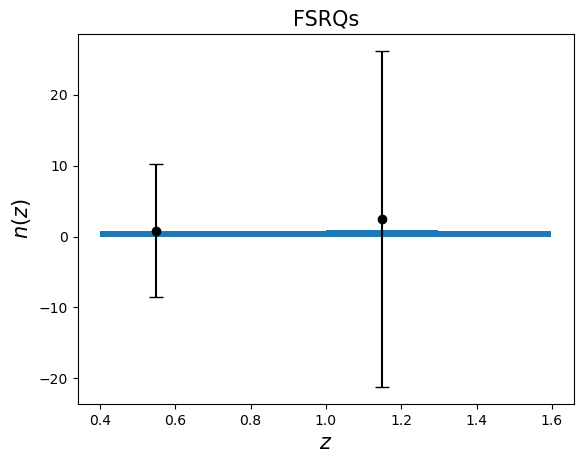

In [92]:
plt.scatter(zs[::2], fsrq_nz[::], color = 'k', zorder = 2)
plt.errorbar(zs[::2], fsrq_nz[::2], yerr = fsrq_err[::2], color = 'k', linestyle = '', capsize = 5, zorder = 3)
blazar_data = fits.open('table-4LAC-DR3-h.fits')[1].data
indices_ = np.where(blazar_data['CLASS'] == 'fsrq')[0].tolist() + np.where(blazar_data['CLASS'] == 'FSRQ')[0].tolist()
indices__ = np.where(((blazar_data['Redshift'][indices_] != np.inf) & (blazar_data['Redshift'][indices_] != -np.inf)) & ((blazar_data['Redshift'][indices_] > 0.4) & (blazar_data['Redshift'][indices_] < 1.6)))
plt.hist(blazar_data['Redshift'][indices_][indices__], bins = 4, density = True) 
plt.title('FSRQs', fontsize = 15)
plt.xlabel(r'$z$', fontsize = 15)
plt.ylabel(r'$n(z)$', fontsize = 15)